# GFSK

## Parameters
- Moving Average Filtering
- Differential Phase
- Instantaneous Frequency
- Frequency Shift

$
x[n] = I[n] + jQ[n]
$

$
d\phi[n] = \arg\left( x[n] \, x^{*}[n-1] \right)
$

$
f_{\text{inst}}[n] = \frac{F_s}{2\pi}\, d\phi[n]
$

$
d\phi_{\text{filt}}[n] = \frac{1}{L}\sum_{k=0}^{L-1} d\phi[n-k]
$

$
f_{\text{inst,filt}}[n] = \frac{F_s}{2\pi}\, d\phi_{\text{filt}}[n]
$

$
\Delta f = \frac{f_{\max} - f_{\min}}{2}
$

$
\Delta f \approx \frac{f_{95\%} - f_{5\%}}{2}
$

$
h = \frac{2\Delta f}{R_s}
$

$
f_{\text{null}} = \frac{F_s}{L}
$

### Load Data From File

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

iq_file = Path(r"ls-OFF-4M-p6M.complex32s")

raw = np.fromfile(iq_file, dtype=np.int16)
i = raw[0::2].astype(np.float32) / 32768.0
q = raw[1::2].astype(np.float32) / 32768.0
iq = i + 1j*q
mag = np.abs(iq)

$
x[n] = I[n] + jQ[n]
$

In [2]:
samp_rate = 4_000_000
samples_per_symbol = 16

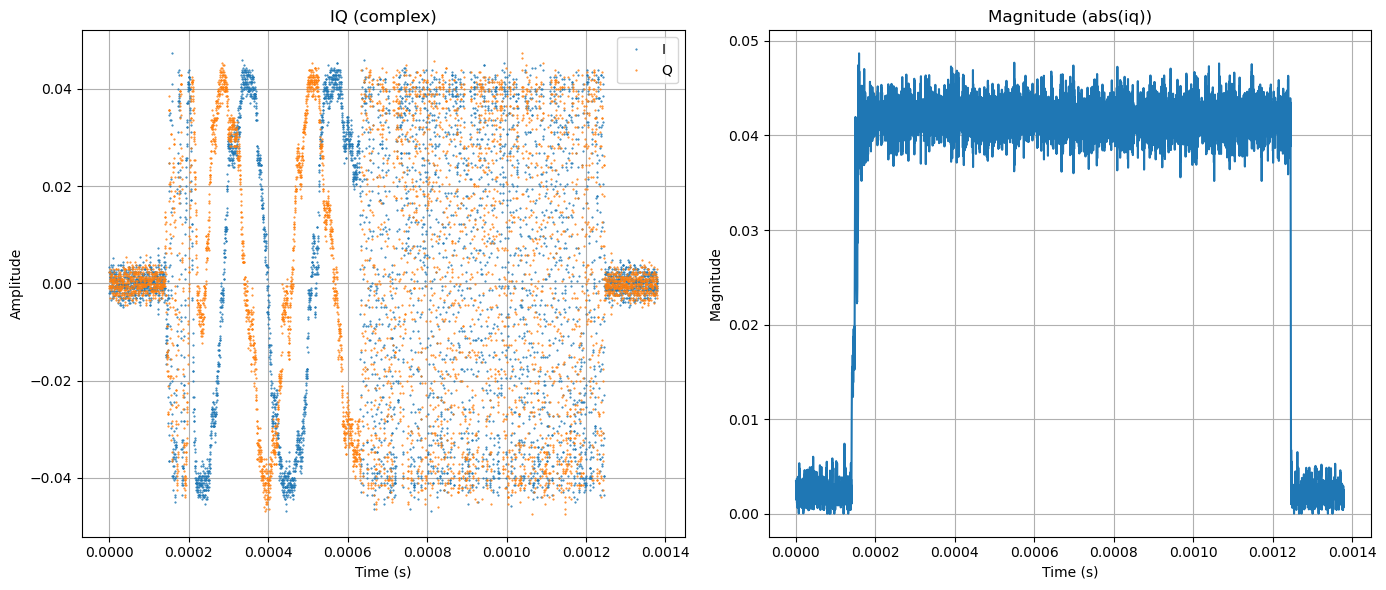

In [3]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(t_iq, iq.real, '.', markersize=marker_size, label='I')
ax1.plot(t_iq, iq.imag, '.', markersize=marker_size, label='Q')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_title("IQ (complex)")
ax1.grid(True)
ax1.legend()

# Right subplot: Magnitude
ax2.plot(t_iq, mag, '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Magnitude")
ax2.set_title("Magnitude (abs(iq))")
ax2.grid(True)

plt.tight_layout()
plt.show()


### Filter Data

#### Moving Average FIR Fileter (boxcar)

$
f_{\text{filt}}[n] = \frac{1}{L}\sum_{k=0}^{L-1} f[n-k]
$

In [4]:
# In the sample we have 16 samples per symbol

L = 16 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

iq_filt = np.convolve(iq, h, mode="same")
mag_filt = np.convolve(mag, h, mode="same")

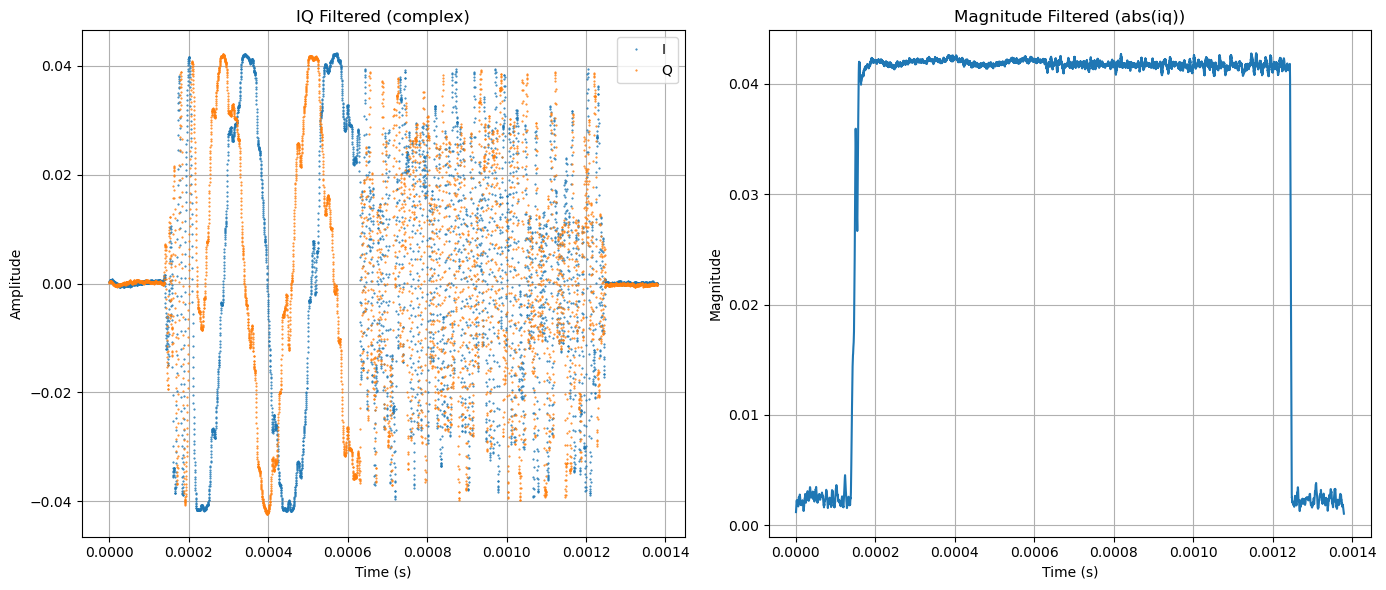

In [5]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(t_iq, iq_filt.real, '.', markersize=marker_size, label='I')
ax1.plot(t_iq, iq_filt.imag, '.', markersize=marker_size, label='Q')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_title("IQ Filtered (complex)")
ax1.grid(True)
ax1.legend()

# Right subplot: Magnitude
ax2.plot(t_iq, mag_filt, '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Magnitude")
ax2.set_title("Magnitude Filtered (abs(iq))")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Differential Phase and Instantaneous Frequency

Differential Phase:

$
\Delta \phi[n] = \angle\left\{ x[n] \cdot x^{*}[n-1] \right\}
$

Instantaneous Frequency:

$
f[n] = \frac{F_s}{2\pi}\,\Delta \phi[n]
$

Carrier Frequency Offset CFO:

$
cfo = \text{mean}(f)
$


#### Compute dPhi first - then filter!

In [6]:
Fs = samp_rate

dphi = np.angle(iq[1:] * np.conj(iq[:-1]))   # in (-pi, pi]
# instantaneous frequency includes Carrier Frequency Offset
inst_freq = (Fs/(2*np.pi)) * dphi  
cfo = np.mean(inst_freq)
print("CFO = {:.1f} kHz".format(cfo/1000))
print("Subtracting CFO from f_inst")

# Subtract CFO
inst_freq -= cfo

CFO = -15.4 kHz
Subtracting CFO from f_inst


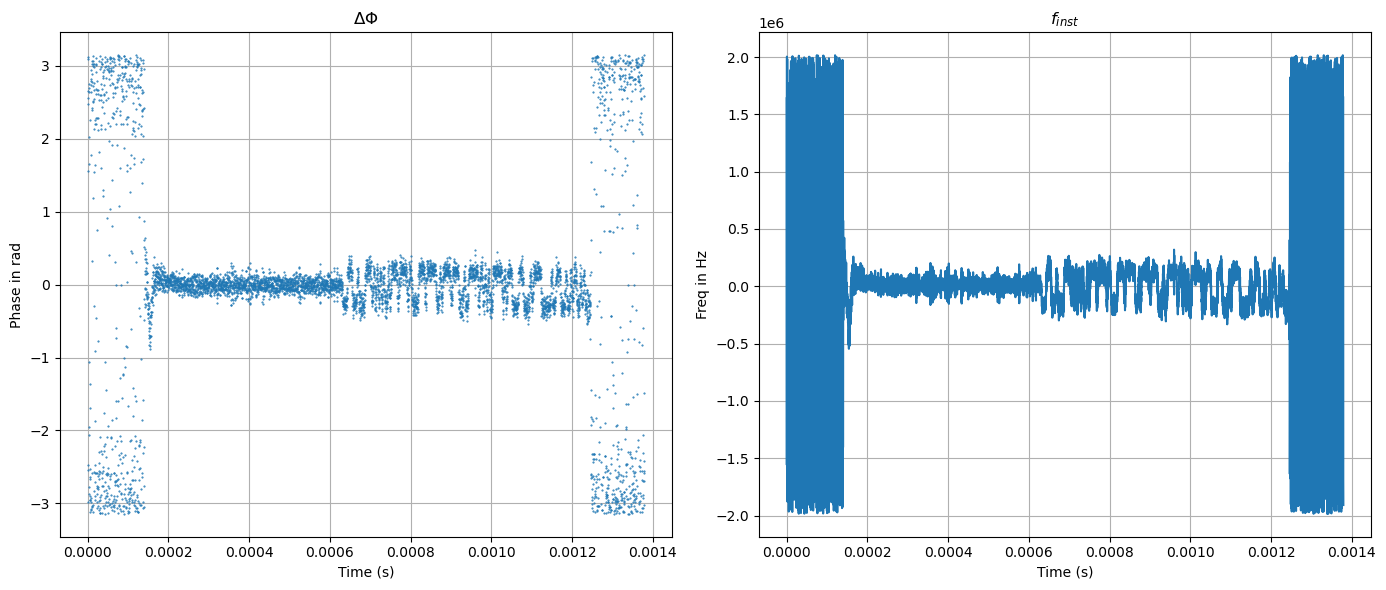

In [7]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(dphi.size) / samp_rate

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(t_iq, dphi, '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(t_iq, inst_freq, '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

plt.tight_layout()
plt.show()

## GFSK Frequency Shift

1. Crop Burst that contains Data
2. Get Frequency Percentiles
3. Calculate Frequency Shift

$
\Delta f = \frac{f_{\max} - f_{\min}}{2}
$

$
\Delta f \approx \frac{f_{95\%} - f_{5\%}}{2}
$

$
R_b ... \text{bit rate}
$

$
h = \frac{2\Delta f}{R_s} \text{... modulation index}
$

$
f_{\text{null}} = \frac{F_s}{L}
$

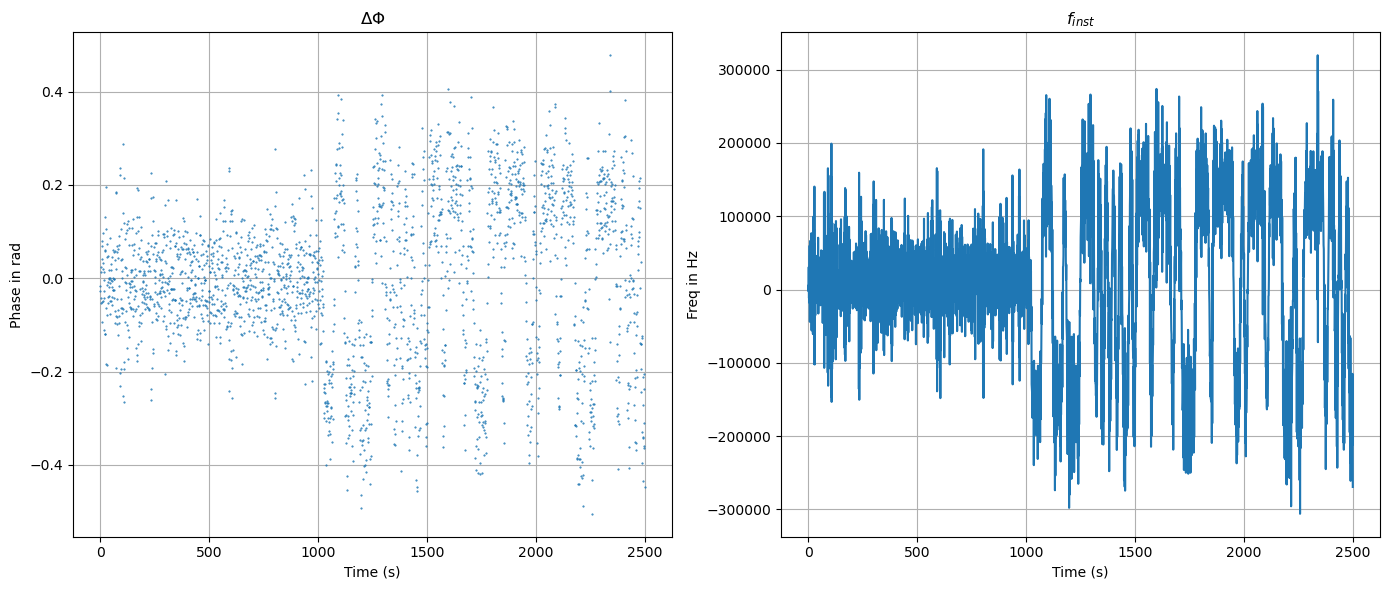

In [8]:
start = 1500 #2000
end = 4000 #3800

fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi[start:end], '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(inst_freq[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Filter
L = 16 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

dphi_filt = np.convolve(dphi, h, mode="same")
inst_freq_filt = np.convolve(inst_freq, h, mode="same")

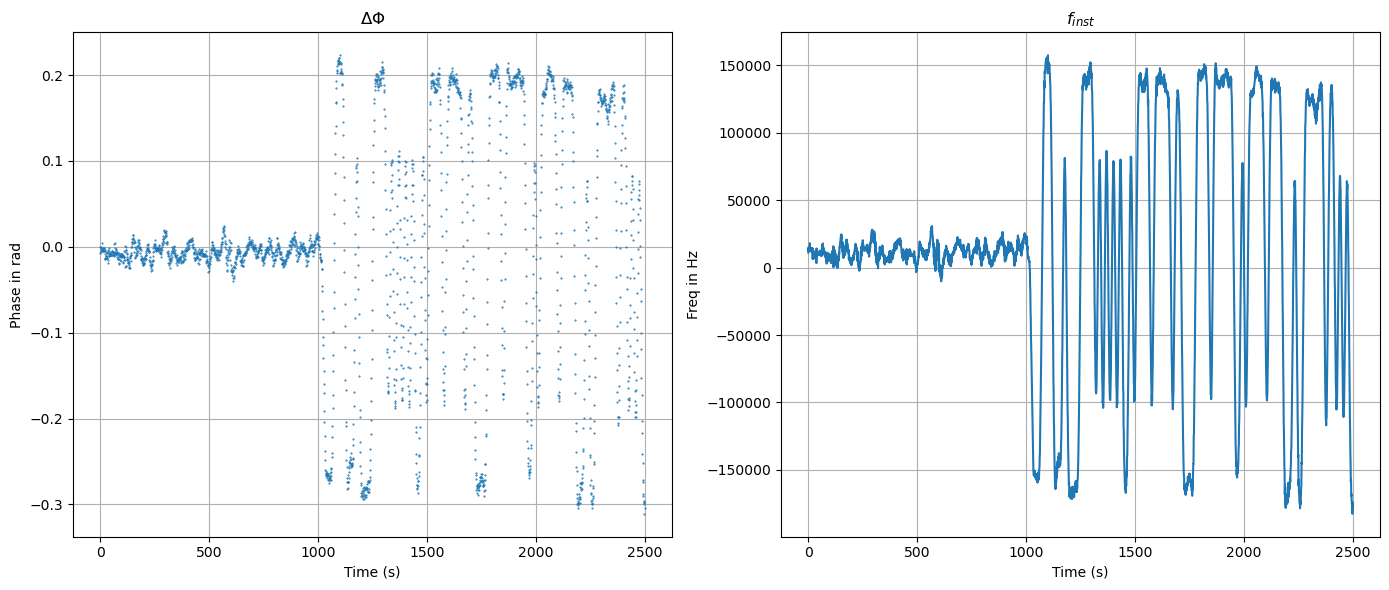

In [10]:
fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi_filt[start:end], '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(inst_freq_filt[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
inst_freq_cropped = inst_freq_filt[start:end]

# Find Min / Max
lo = np.percentile(inst_freq_cropped, 5)
hi = np.percentile(inst_freq_cropped, 95)

delta_f = (hi - lo) / 2
print("f_hi ≈ {:+.1f} kHz".format(hi/1000))
print("f_lo ≈ {:+.1f} kHz".format(lo/1000))
print("f_mid ≈ {:+.1f} kHz".format((hi+lo)/2/1000)) # residual CFO/bias
print("Δf ≈ {:.1f} kHz".format(delta_f/1000))

f_hi ≈ +141.8 kHz
f_lo ≈ -158.5 kHz
f_mid ≈ -8.3 kHz
Δf ≈ 150.2 kHz


In [12]:
# Modulation index h
BR = 250_000
h = 2.0*delta_f/BR
print("Modulation Index = {:.2f}".format(h))

Modulation Index = 1.20


# Gnuradio GFSK Decoding

## Works great on short file

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS (edit)
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
#iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16

# Quad Gain
df = 150_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11
#quad_gain = 4.11
n_plot = 20000  # complex samples captured for plotting
# -----------------------------

tb = gr.top_block("tap_each_stage")

# Source: int16 stream I0,Q0,I1,Q1,...
src = blocks.file_source(gr.sizeof_short, iq_file, False)

# Split interleaved shorts into I and Q streams
deint = blocks.deinterleave(gr.sizeof_short)

# int16 -> float ~[-1, 1]
# i_f = blocks.short_to_float(1, 1.0 / 32768.0)
# q_f = blocks.short_to_float(1, 1.0 / 32768.0)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)

# float I/Q -> complex
iq_c = blocks.float_to_complex(1)

# Limit run length (complex samples)
head_c = blocks.head(gr.sizeof_gr_complex, n_plot)

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF
# sym_rate = samp_rate / float(samples_per_symbol)
# lpf_taps = firdes.low_pass(1.0, samp_rate, 0.45 * sym_rate, 0.20 * sym_rate, WIN)
# lpf = filter.fir_filter_fff(1, lpf_taps)
# Replace the sym_rate-derived LPF with a deviation-friendly LPF
lpf_cutoff_hz = 350_000   # try 250k, 350k, 450k
lpf_trans_hz  = 100_000

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()

# ---- connections ----
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Use the same limited IQ stream for all downstream taps
tb.connect(iq_c, head_c)

tb.connect(head_c, tap_iq)
tb.connect(head_c, fsk_disc)
tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)

tb.run()

# ---- pull data for plotting ----
iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")


Captured: IQ=5518 complex, disc=5518, lpf=5518, clk=347, bits=347


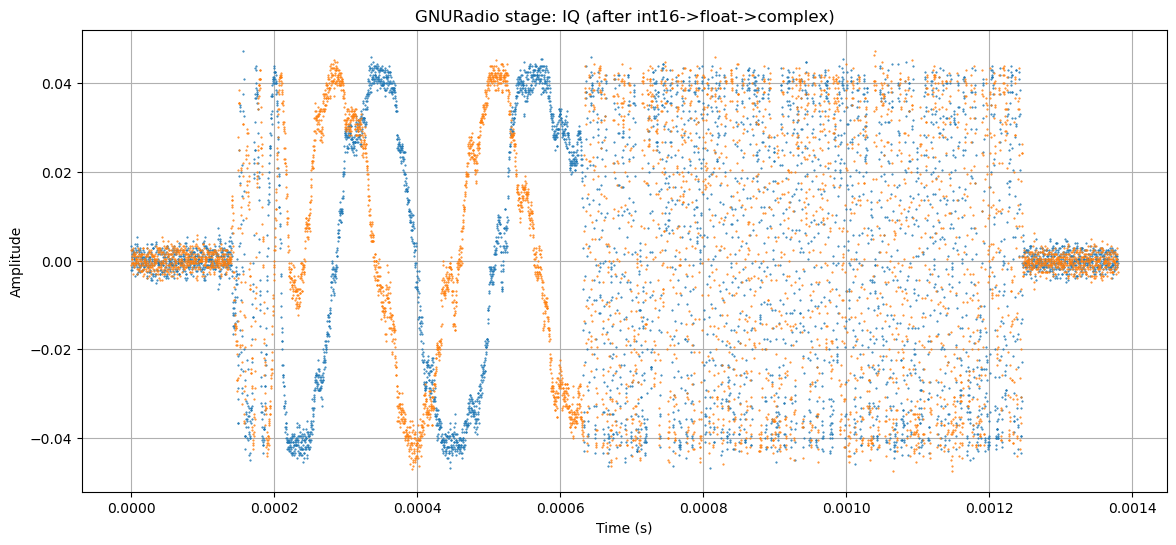

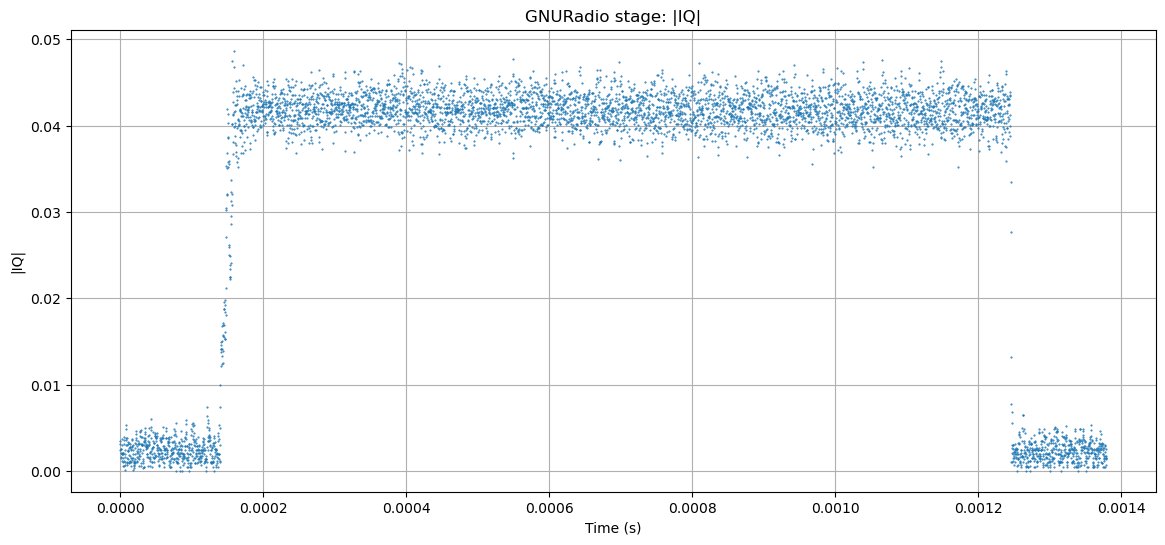

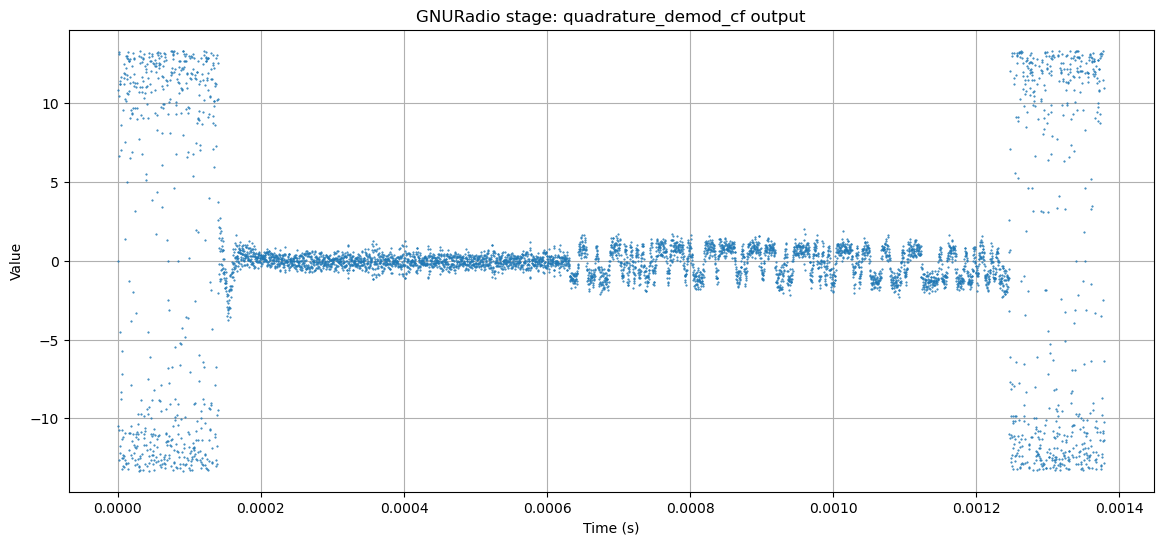

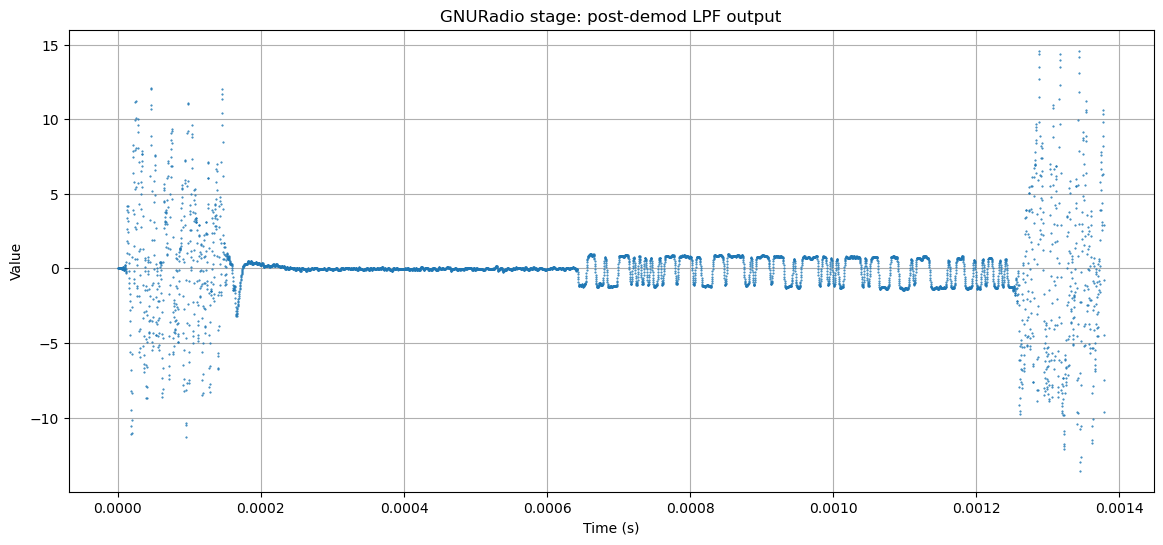

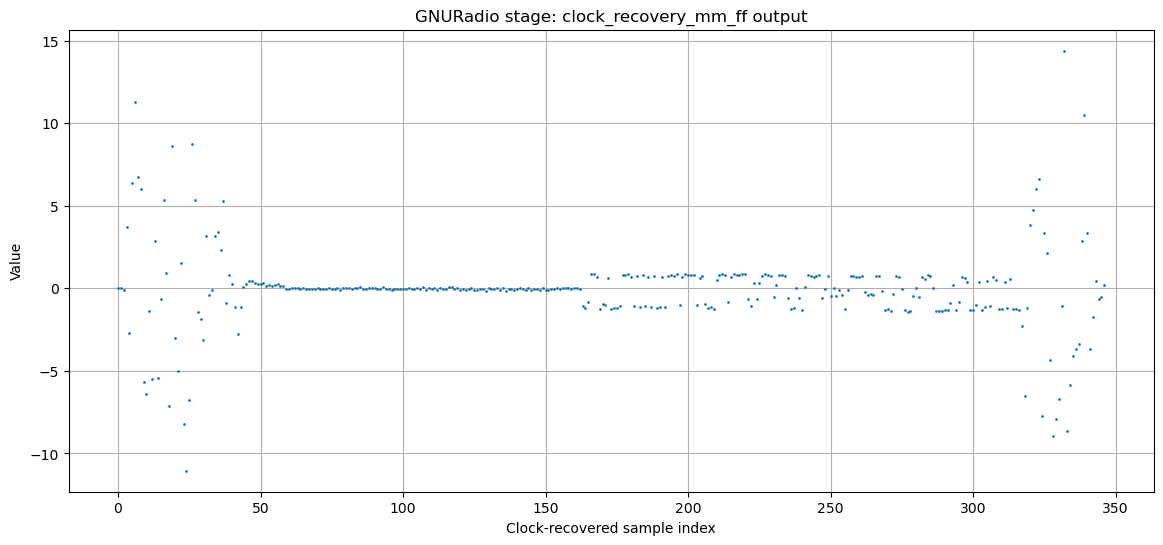

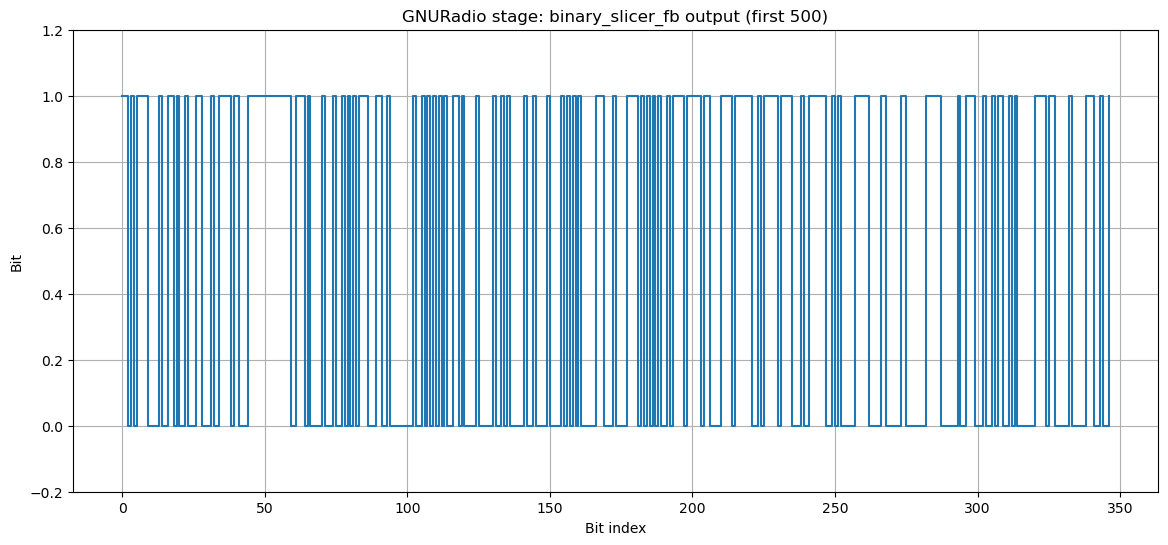

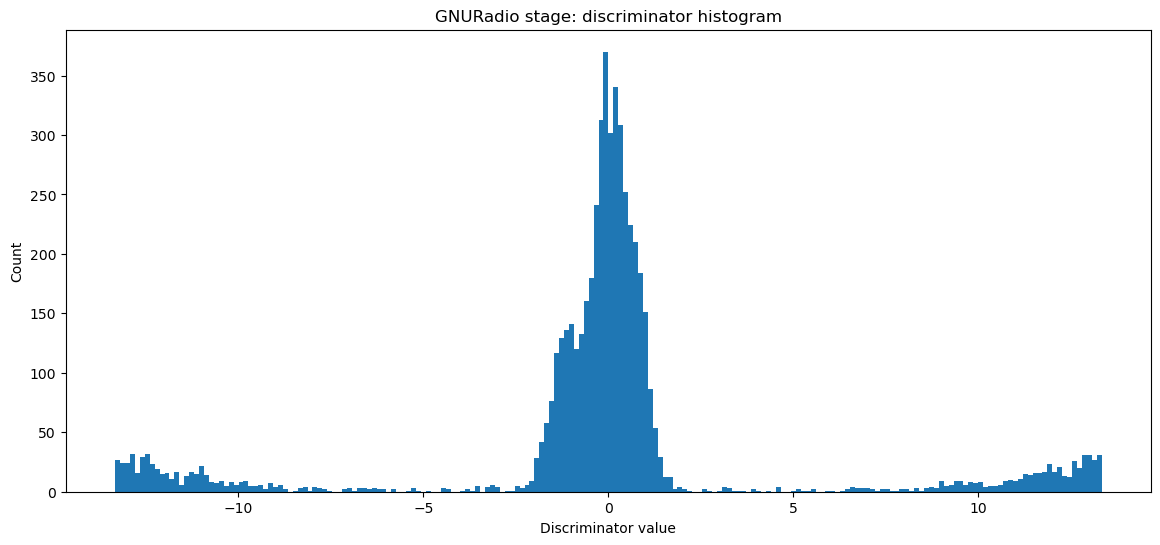

In [14]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()

In [15]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
#pattern_str = "1110001"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]
print(indices)

[166]


# Moving Average Filter

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS (edit)
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
symbol_rate = 250_000
samples_per_symbol = int(samp_rate/symbol_rate)
print("Samples per symbol =", samples_per_symbol)

# Quad Gain
df = 150_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# Post-demod Filtering
filter_type_list = ["fir", "moving_average"]
filter_type = filter_type_list[1]
if filter_type == "fir":
    print("Using FIR post-demod filter")
    lpf_cutoff_hz = 350_000  
    lpf_trans_hz  = 100_000
elif filter_type == "moving_average":
    print("Using moving average post-demod filter")
    ma_symbols = 1.0  # try 0.5, 1.0, 1.5, 2.0
    ma_len = max(1, int(round(ma_symbols * samples_per_symbol)))
    ma_len = 2
    ma_taps = [1.0 / ma_len] * ma_len

n_plot = 20000  # complex samples captured for plotting
# -----------------------------

tb = gr.top_block("tap_each_stage")

# Source: int16 stream I0,Q0,I1,Q1,...
src = blocks.file_source(gr.sizeof_short, iq_file, False)

# Split interleaved shorts into I and Q streams
deint = blocks.deinterleave(gr.sizeof_short)

# int16 -> float ~[-1, 1]
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)

# float I/Q -> complex
iq_c = blocks.float_to_complex(1)

# Limit run length (complex samples)
head_c = blocks.head(gr.sizeof_gr_complex, n_plot)

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
if filter_type == "fir":
    lpf = filter.fir_filter_fff(1, lpf_taps)
elif filter_type == "moving_average":
    lpf = filter.fir_filter_fff(1, ma_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()

# ---- connections ----
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Use the same limited IQ stream for all downstream taps
tb.connect(iq_c, head_c)

tb.connect(head_c, tap_iq)
tb.connect(head_c, fsk_disc)
tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)

tb.run()

# ---- pull data for plotting ----
iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")


Samples per symbol = 16
Using moving average post-demod filter
Captured: IQ=20000 complex, disc=20000, lpf=20000, clk=1228, bits=1228


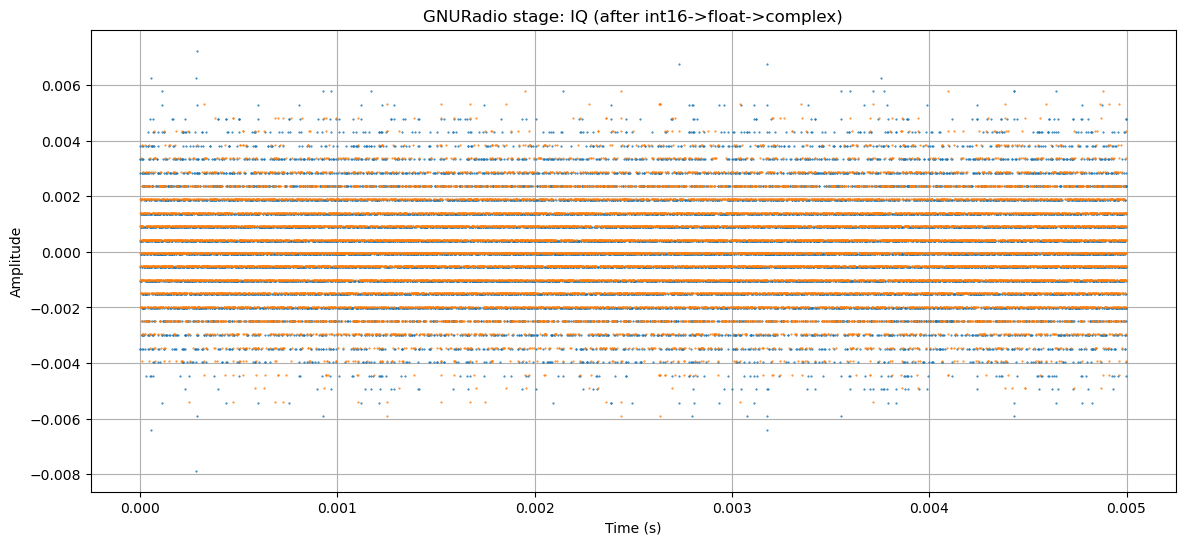

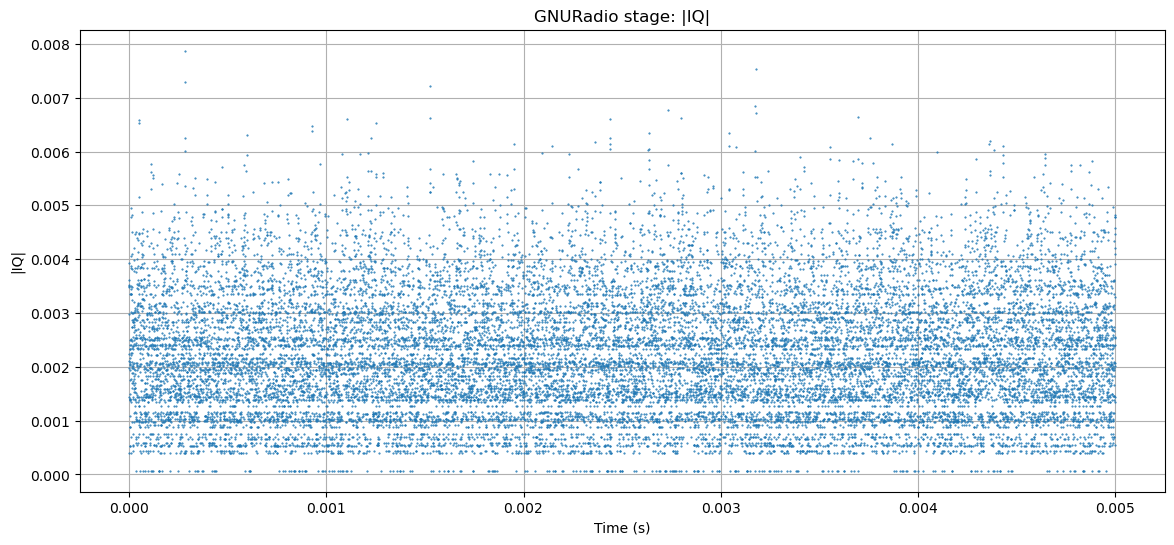

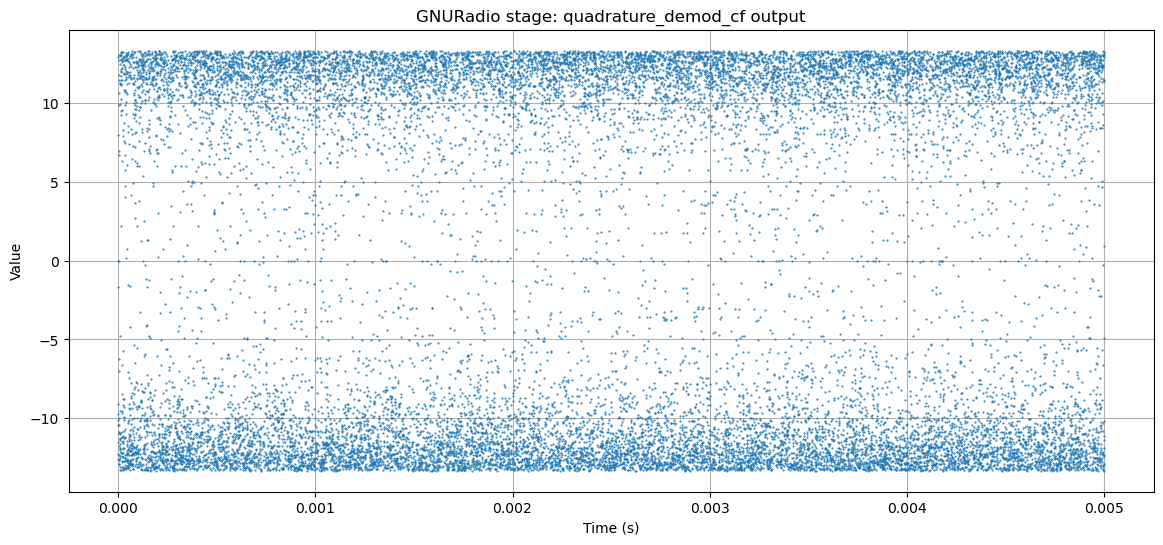

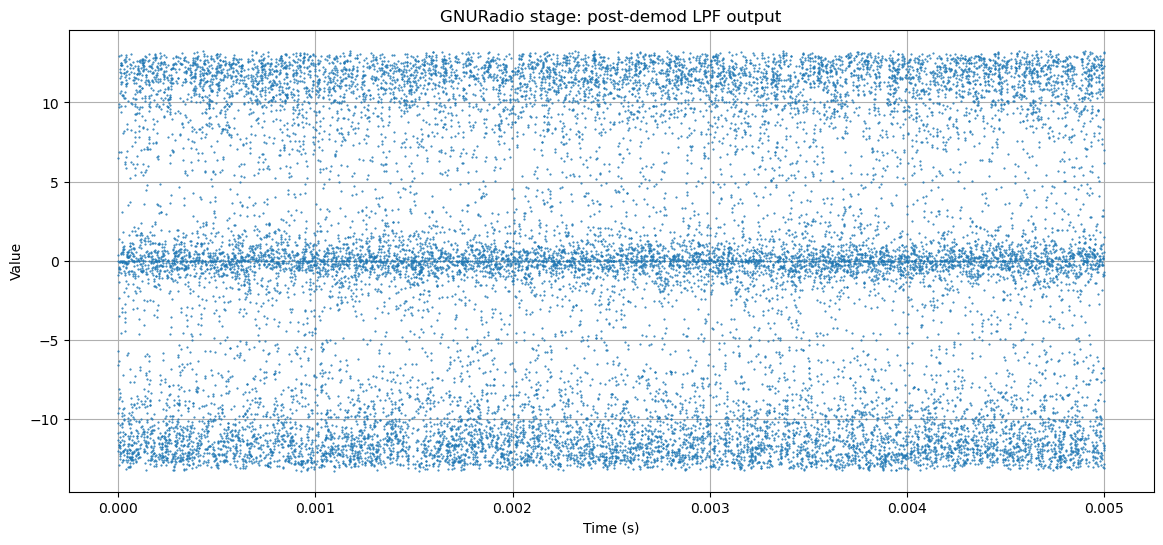

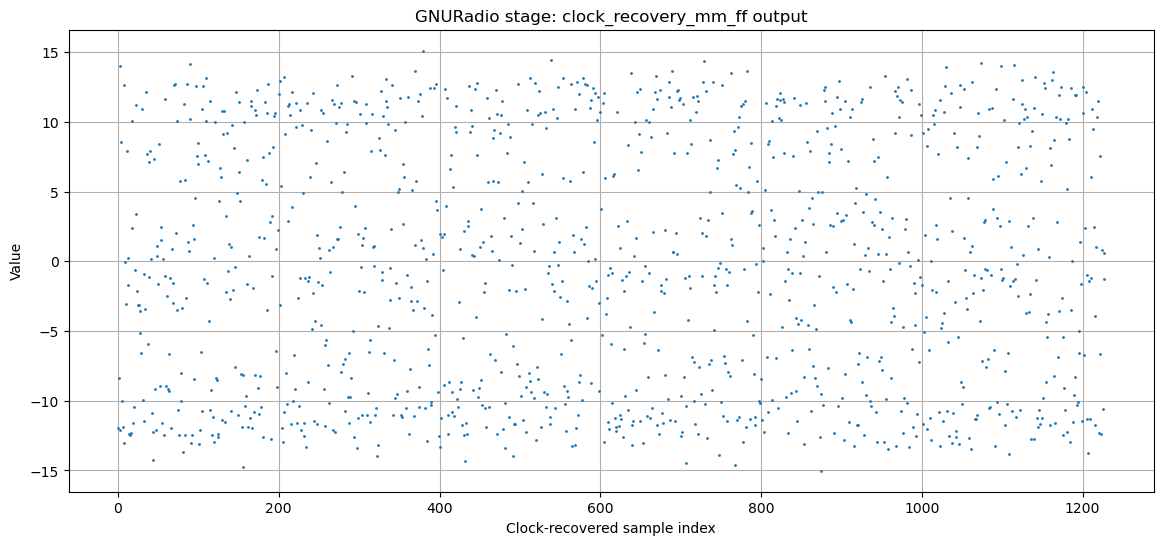

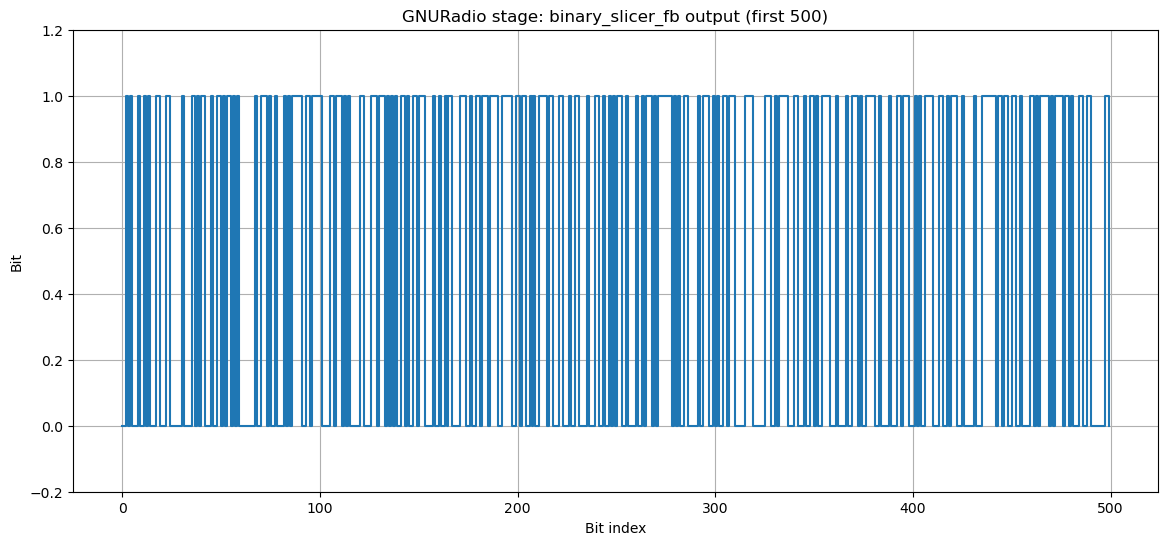

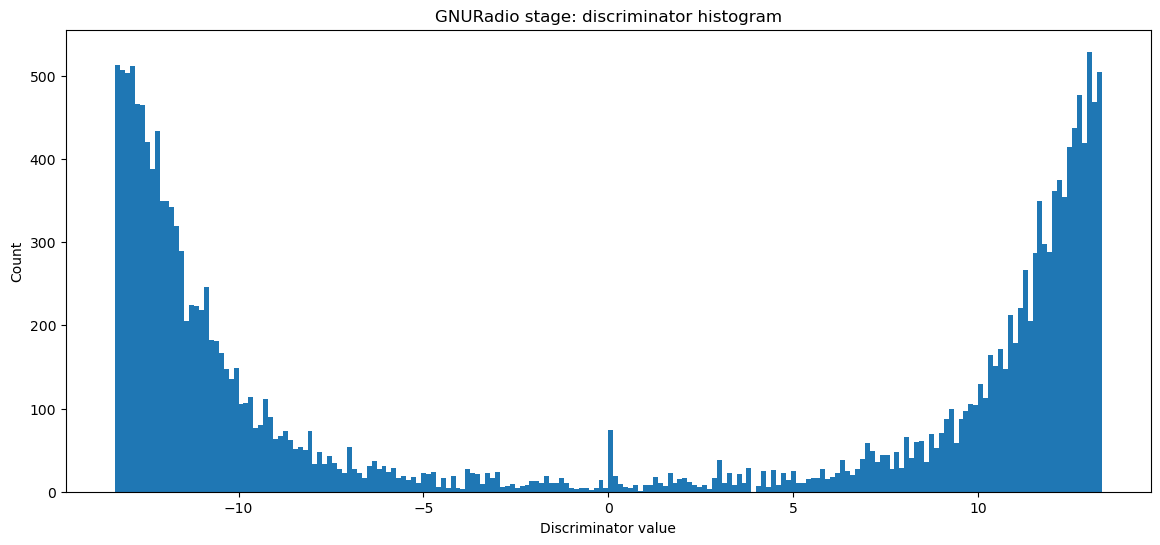

In [17]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()

In [18]:
bits.shape

(1228,)

In [19]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001000011110101010100101111011111"

pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]
print(indices)

[]


## Adding Masking for Demodulaltion, otherwise magnitude of quadrature_demod is way off

# New code with new blocks

Done. Wrote ALL decoded bits to: out_bits.bin


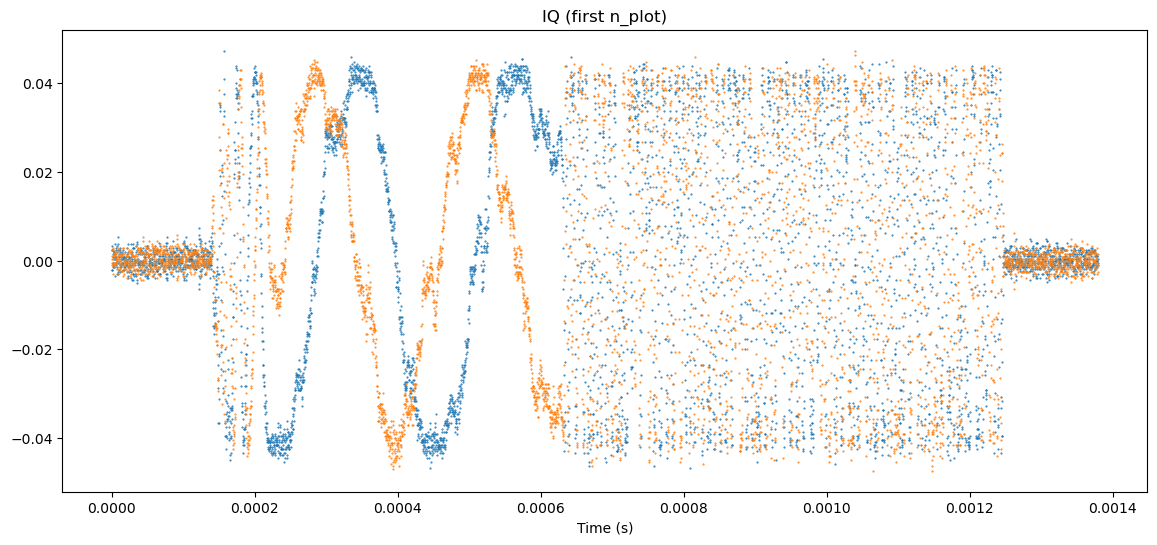

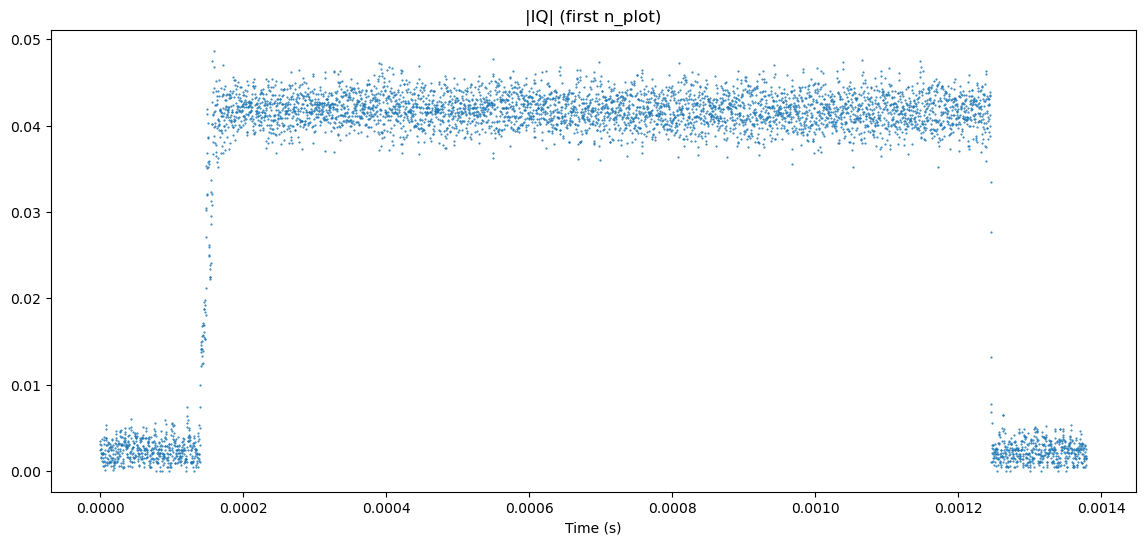

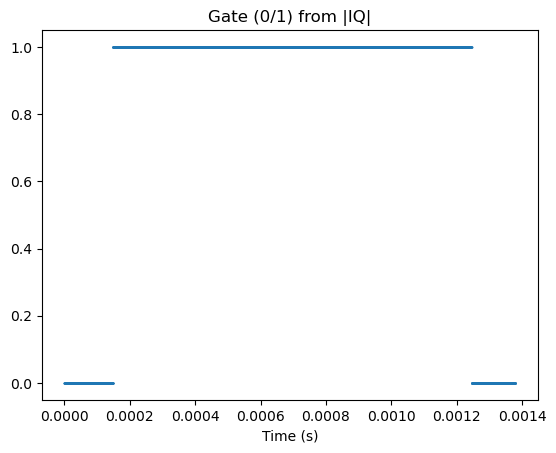

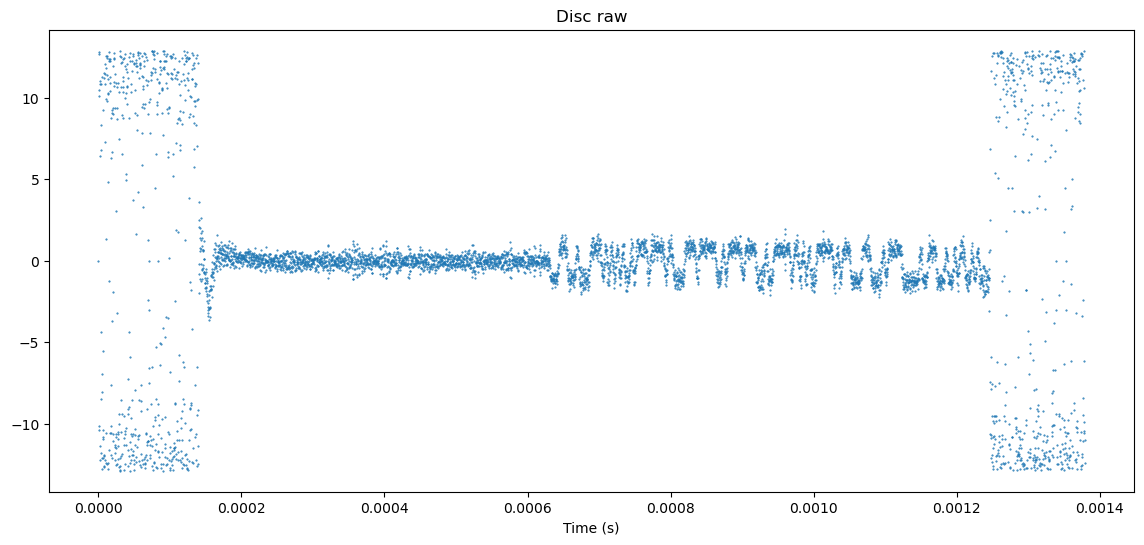

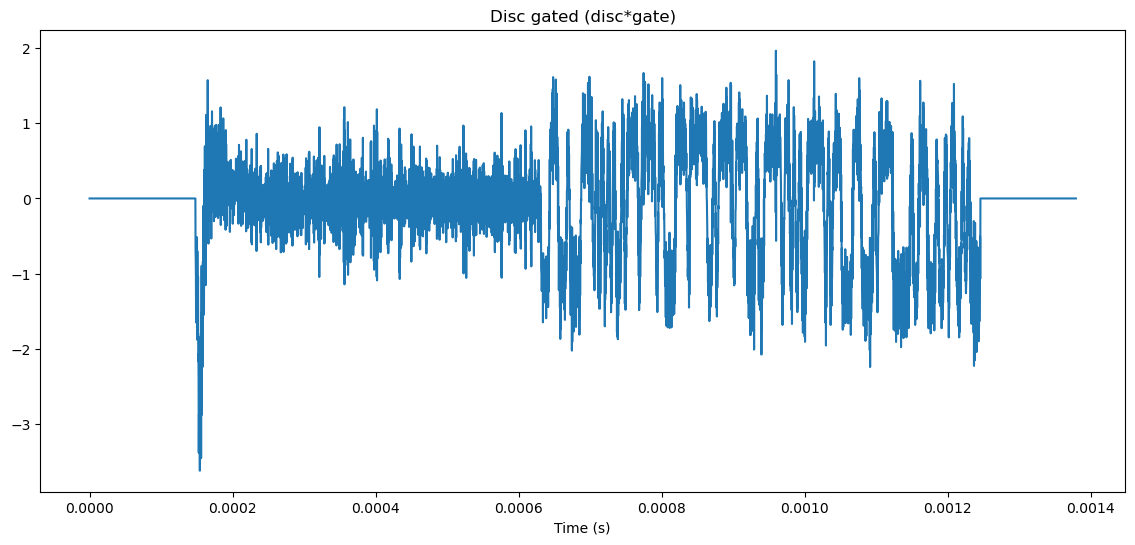

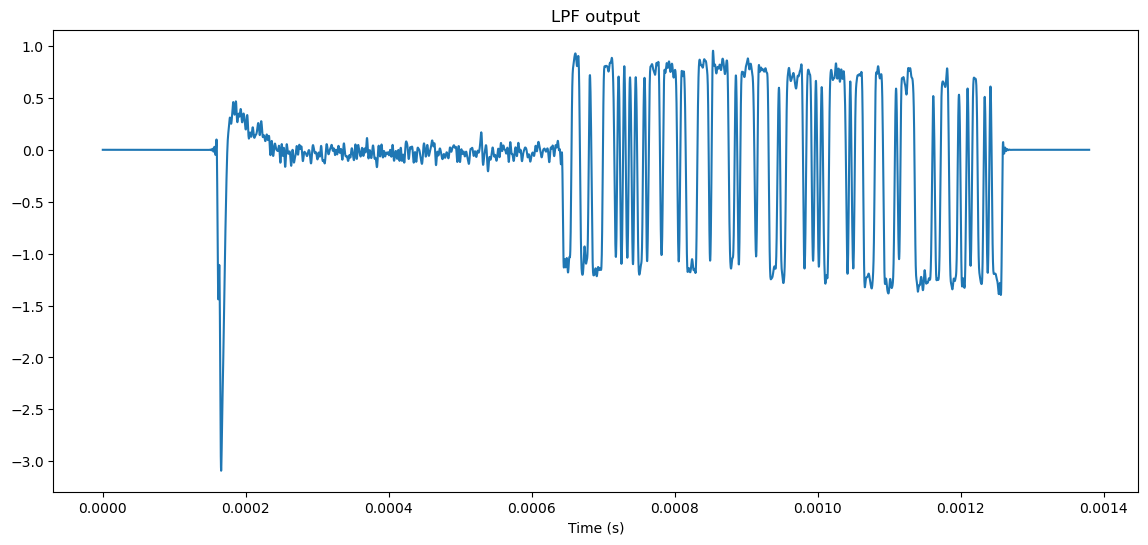

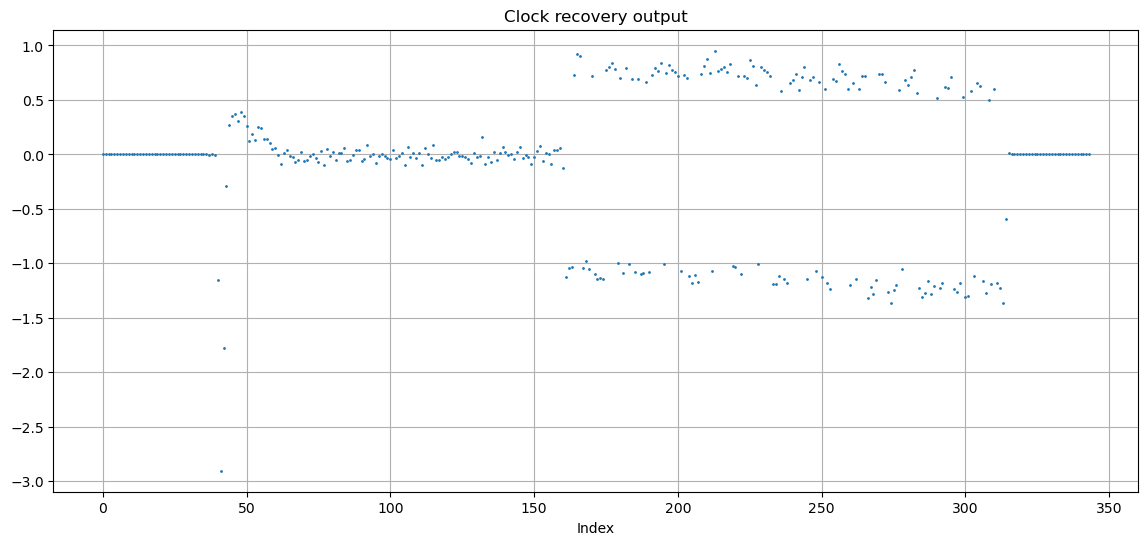

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M.complex32s"
#iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
out_bits_file = "out_bits.bin"            # FULL decoded bits (bytes 0/1)

samp_rate = 4_000_000
samples_per_symbol = 16

# Quadrature demod gain: normalize to ~±1 for ±df
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# LPF on discriminator
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Gate thresholds on |IQ| (tune these!)
# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.03 # above -> gate=1  (hysteresis)
gate_lo = 0.02 # below -> gate=0
gate_initial = 0

# tap files (FULL streams)
tap_iq_file   = "tap_iq.c64"
tap_mag_file  = "tap_mag.f32"
tap_gate_file = "tap_gate.f32"
tap_disc_file = "tap_disc.f32"
tap_dg_file   = "tap_disc_gated.f32"
# tap_rail_file = "tap_disc_rail.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"
tap_bits_file = "tap_bits.u8"

n_plot = 20000  # plotting only
# -----------------------------

tb = gr.top_block("fsk_burst_gate_then_mm")

# Source: int16 I,Q
src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

# Magnitude -> gate
mag = blocks.complex_to_mag(1)
gate = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)   # outputs 0.0 or 1.0

# Demod
demod = analog.quadrature_demod_cf(float(quad_gain))

# Gate discriminator (disc * gate)
disc_gate = blocks.multiply_ff(1)

# LPF
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery + slicer
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)
slicer = digital.binary_slicer_fb()

# Main output
bits_sink = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# Tap sinks
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_mag_sink  = blocks.file_sink(gr.sizeof_float,      tap_mag_file, False)
tap_gate_sink = blocks.file_sink(gr.sizeof_float,      tap_gate_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_dg_sink   = blocks.file_sink(gr.sizeof_float,      tap_dg_file, False)
# tap_rail_sink = blocks.file_sink(gr.sizeof_float,      tap_rail_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file,  False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file,  False)
tap_bits_sink = blocks.file_sink(gr.sizeof_char,       tap_bits_file, False)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# Tap IQ
tb.connect(iq_c, tap_iq_sink)

# Magnitude + gate taps
tb.connect(iq_c, mag)
tb.connect(mag, tap_mag_sink)
tb.connect(mag, gate)
tb.connect(gate, tap_gate_sink)

# Demod + tap
tb.connect(iq_c, demod)
tb.connect(demod, tap_disc_sink)

# disc * gate
tb.connect(demod, (disc_gate, 0))
tb.connect(gate,  (disc_gate, 1))
tb.connect(disc_gate, tap_dg_sink)

# LPF + tap
tb.connect(disc_gate, lpf)
tb.connect(lpf, tap_lpf_sink)

# Clock recovery + tap
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk_sink)

# Bits + taps
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits_sink)
tb.connect(slicer, bits_sink)

tb.run()
print("Done. Wrote ALL decoded bits to:", out_bits_file)

# -----------------------------
# Plot first n_plot samples
# -----------------------------
def read_c64(path, n): return np.fromfile(path, dtype=np.complex64, count=n)
def read_f32(path, n): return np.fromfile(path, dtype=np.float32,  count=n)
def read_u8(path, n):  return np.fromfile(path, dtype=np.uint8,    count=n)

iq   = read_c64(tap_iq_file, n_plot)
magv = read_f32(tap_mag_file, n_plot)
gatev= read_f32(tap_gate_file, n_plot)
disc = read_f32(tap_disc_file, n_plot)
dg   = read_f32(tap_dg_file, n_plot)
# railv= read_f32(tap_rail_file, n_plot)
lpfv = read_f32(tap_lpf_file,  n_plot)
clk  = read_f32(tap_clk_file,  n_plot)
bits = read_u8(tap_bits_file,  min(n_plot, 5000))

fig_size = (14, 6)
marker_size = 1

t = np.arange(len(disc)) / samp_rate
t_iq = np.arange(len(iq)) / samp_rate

plt.figure(figsize=fig_size); 
plt.plot(t_iq, iq.real, '.', markersize=1); plt.plot(t_iq, iq.imag, '.', markersize=1)
plt.title("IQ (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, magv, '.', markersize=1); plt.title("|IQ| (first n_plot)"); plt.xlabel("Time (s)"); plt.show()

plt.figure();  
plt.plot(t, gatev, '.', markersize=1); plt.title("Gate (0/1) from |IQ|"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, disc, '.', markersize=1); plt.title("Disc raw"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, dg, markersize=1); plt.title("Disc gated (disc*gate)"); plt.xlabel("Time (s)"); plt.show()
# plt.figure(); plt.plot(t, railv,'.', markersize=1); plt.title("Disc gated + railed"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(t, lpfv, markersize=1); plt.title("LPF output"); plt.xlabel("Time (s)"); plt.show()

plt.figure(figsize=fig_size); 
plt.plot(clk, '.', markersize=2); plt.title("Clock recovery output"); plt.xlabel("Index"); plt.grid(); plt.show()

# plt.figure(figsize=fig_size); 
# m = min(500, len(bits)); plt.step(np.arange(m), bits[:m], where="post"); plt.ylim(-0.2, 1.2)
# plt.title("Bits (first 500)"); plt.xlabel("Bit index"); plt.show()


In [3]:
bits.shape

(344,)

In [4]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[164]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

iq_file = Path(r"ls-OFF-4M-p6M.complex32s")

raw = np.fromfile(iq_file, dtype=np.int16)
i = raw[0::2].astype(np.float32) / 32768.0
q = raw[1::2].astype(np.float32) / 32768.0
x = i + 1j*q
mag = np.abs(x)

In [6]:
print('np.min(max) =', np.min(mag))
print('np.max(max) =', np.max(mag))

np.min(max) = 3.0517578e-05
np.max(max) = 0.04866245


In [157]:
import os, numpy as np
p="tap_mag.f32"
print("bytes:", os.path.getsize(p), "mod4:", os.path.getsize(p)%4)
a = np.fromfile(p, dtype=np.float32, count=10)
print(a)


bytes: 22072 mod4: 0
[0.0034668  0.00314153 0.00240005 0.00206552 0.00253314 0.00159306
 0.00145751 0.0025682  0.00298074 0.00373189]


# Check Gnuradio file read

In [21]:
import numpy as np
from gnuradio import gr, blocks

N = 100_000
iq_file = "ls-OFF-4M-p6M.complex32s"

tb = gr.top_block()

src = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f = blocks.short_to_float(1, 32768.0)
q_f = blocks.short_to_float(1, 32768.0)
iq_c = blocks.float_to_complex(1)

head = blocks.head(gr.sizeof_gr_complex, N)
sink = blocks.vector_sink_c()

tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))
tb.connect(iq_c, head, sink)

tb.run()

iq = np.asarray(sink.data(), dtype=np.complex64)
print("iq dtype:", iq.dtype, "len:", len(iq))
print("iq.real min/max:", iq.real.min(), iq.real.max())
print("iq.imag min/max:", iq.imag.min(), iq.imag.max())
print("|iq| min/max:", np.abs(iq).min(), np.abs(iq).max())

iq dtype: complex64 len: 5518
iq.real min/max: -0.046875 0.047332764
iq.imag min/max: -0.0473938 0.047302246
|iq| min/max: 3.0517578e-05 0.04866245


# Burst_tag block with gnuradio

Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger59
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger59
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger59
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger59
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger59
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger59
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger59
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger59
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger59
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger59


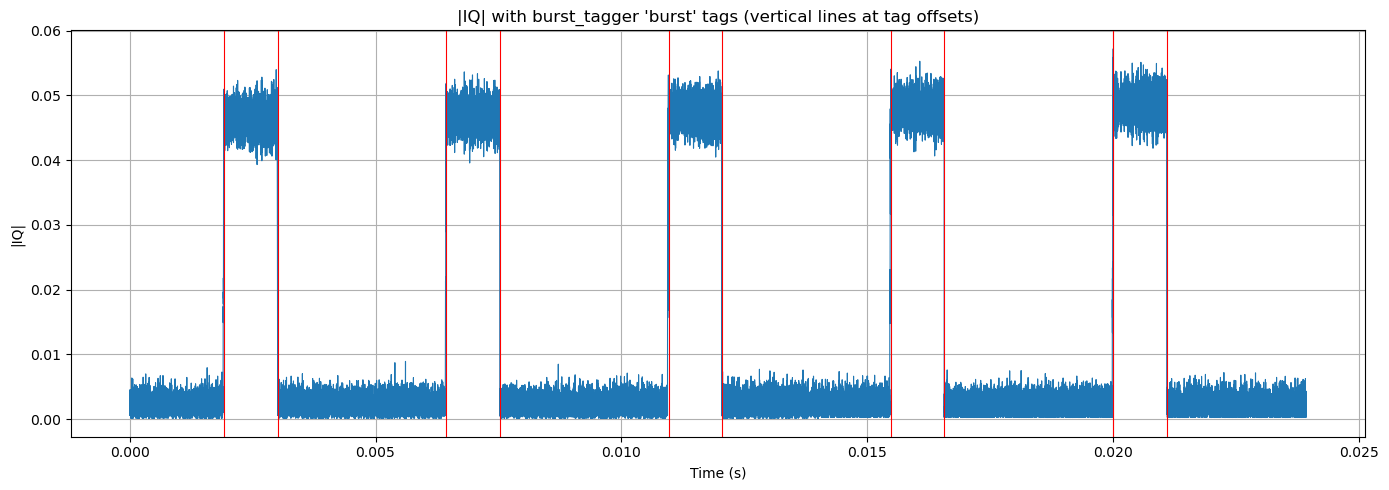

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M.complex32s" 
# iq_file = r"ls-OFF-4M-p6M-02.complex32s"  # int16 interleaved I,Q
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000

n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # default key name used by burst_tagger docs



tap_ma = blocks.vector_sink_f()


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q  (your starting point)
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0 float

# Convert gate 0/1 -> trigger short +/-1
# map: 0 -> -1, 1 -> +1
#  gatef: 0 or 1
#  gatef - 0.5 -> -0.5 or +0.5
#  *2 -> -1 or +1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger short stream (+/-)

tb.connect(bt, head)
tb.connect(head, vsink)


tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


tags = list(vsink.tags())

burst_tags = [t for t in tags if str(t.key) == tag_key]
print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    print(f"tag: offset={t.offset}, key={t.key}, value={t.value}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| with burst_tagger 'burst' tags (vertical lines at tag offsets)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")

for tt in burst_tags:
    idx = int(tt.offset)
    if 0 <= idx < len(x):
        plt.axvline(idx / samp_rate, linewidth=0.8, color='red')

plt.grid(True)
plt.tight_layout()
plt.show()


# Burst Tag Gate

## Tag Gate Pass Blocks

Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger67
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger67
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger67
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger67
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger67
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger67
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger67
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger67
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger67
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger67


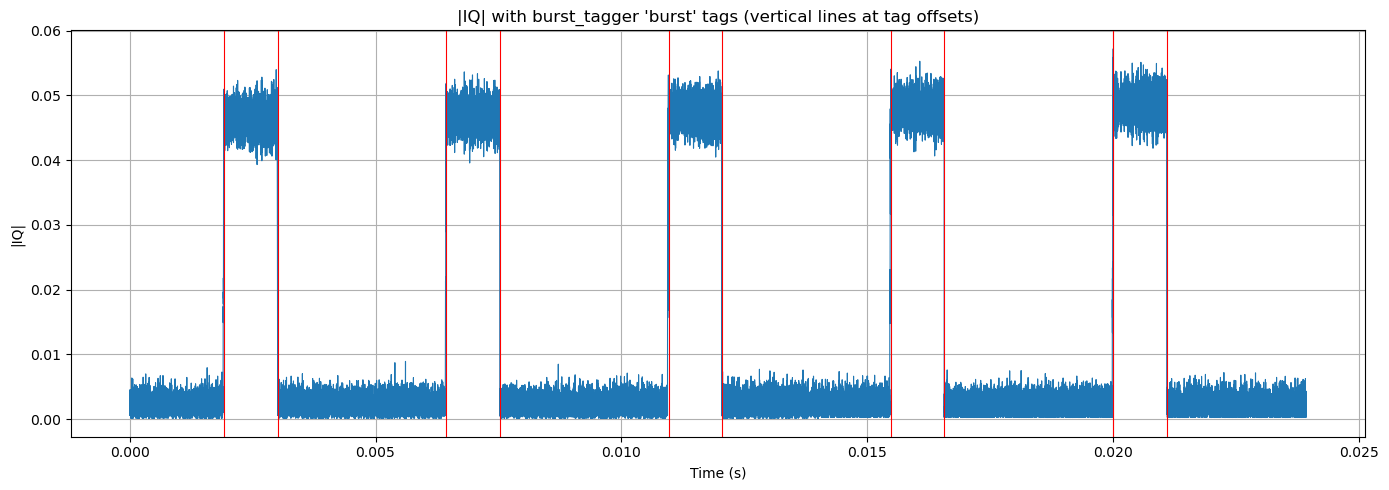

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M.complex32s" 
# iq_file = r"ls-OFF-4M-p6M-02.complex32s"  # int16 interleaved I,Q
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000

n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # default key name used by burst_tagger docs



tap_ma = blocks.vector_sink_f()


# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q  (your starting point)
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0 float

# Convert gate 0/1 -> trigger short +/-1
# map: 0 -> -1, 1 -> +1
#  gatef: 0 or 1
#  gatef - 0.5 -> -0.5 or +0.5
#  *2 -> -1 or +1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger short stream (+/-)

tb.connect(bt, head)
tb.connect(head, vsink)


tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


tags = list(vsink.tags())

burst_tags = [t for t in tags if str(t.key) == tag_key]
print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    print(f"tag: offset={t.offset}, key={t.key}, value={t.value}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| with burst_tagger 'burst' tags (vertical lines at tag offsets)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")

for tt in burst_tags:
    idx = int(tt.offset)
    if 0 <= idx < len(x):
        plt.axvline(idx / samp_rate, linewidth=0.8, color='red')

plt.grid(True)
plt.tight_layout()
plt.show()


## With pass-gate

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks
import pmt

# -----------------------------
# Tag-gated pass block (complex)
# -----------------------------
class burst_tag_gate_cc(gr.sync_block):
    """
    Mute (output 0+0j) when not inside a burst, based on a burst tag.
    Burst state is controlled by tags with key==tag_key:

      - If tag value is integer:
          >0  => enter burst
          <=0 => exit burst
      - If tag value is bool:
          True  => enter burst
          False => exit burst
      - If tag value is PMT NIL:
          treat as "start" (enter burst)

    Tags are propagated downstream.
    """
    def __init__(self, tag_key="burst", start_on_nil=True, initial_in_burst=False):
        gr.sync_block.__init__(
            self,
            name="burst_tag_gate_cc",
            in_sig=[np.complex64],
            out_sig=[np.complex64],
        )
        self.tag_key = pmt.intern(tag_key)
        self.start_on_nil = bool(start_on_nil)
        self.in_burst = bool(initial_in_burst)

        # Ensure tags propagate
        try:
            self.set_tag_propagation_policy(gr.TPP_ALL_TO_ALL)
        except Exception:
            pass

    def _value_to_state(self, v):
        # NIL => usually "start"
        if pmt.is_null(v):
            return True if self.start_on_nil else None

        # Integer?
        if pmt.is_integer(v):
            return pmt.to_long(v) > 0

        # Bool?
        if pmt.is_bool(v):
            return bool(pmt.to_bool(v))

        # Fallback: try string parse
        try:
            s = pmt.write_string(v)
            if s in ("#t", "true", "True", "1"):
                return True
            if s in ("#f", "false", "False", "0"):
                return False
        except Exception:
            pass

        # Unknown -> ignore
        return None

    def work(self, input_items, output_items):
        x = input_items[0]
        y = output_items[0]
        n = len(x)

        abs0 = self.nitems_read(0)
        tags = self.get_tags_in_window(0, 0, n)
        tags.sort(key=lambda t: t.offset)

        # Default fill for this window based on current state
        if self.in_burst:
            y[:] = x
        else:
            y[:] = 0.0 + 0.0j

        # Apply transitions at tag offsets
        for t in tags:
            if t.key != self.tag_key:
                continue

            rel = int(t.offset - abs0)
            if rel < 0 or rel >= n:
                continue

            new_state = self._value_to_state(t.value)
            if new_state is None:
                continue

            self.in_burst = new_state
            if self.in_burst:
                y[rel:] = x[rel:]
            else:
                y[rel:] = 0.0 + 0.0j

        return n

Captured 95713 complex samples
Total tags captured: 10
'burst' tags captured: 10
tag: offset=7692, key=burst, value=#t, srcid=burst_tagger13
tag: offset=12050, key=burst, value=#f, srcid=burst_tagger13
tag: offset=25767, key=burst, value=#t, srcid=burst_tagger13
tag: offset=30124, key=burst, value=#f, srcid=burst_tagger13
tag: offset=43839, key=burst, value=#t, srcid=burst_tagger13
tag: offset=48199, key=burst, value=#f, srcid=burst_tagger13
tag: offset=61912, key=burst, value=#t, srcid=burst_tagger13
tag: offset=66273, key=burst, value=#f, srcid=burst_tagger13
tag: offset=80010, key=burst, value=#t, srcid=burst_tagger13
tag: offset=84372, key=burst, value=#f, srcid=burst_tagger13


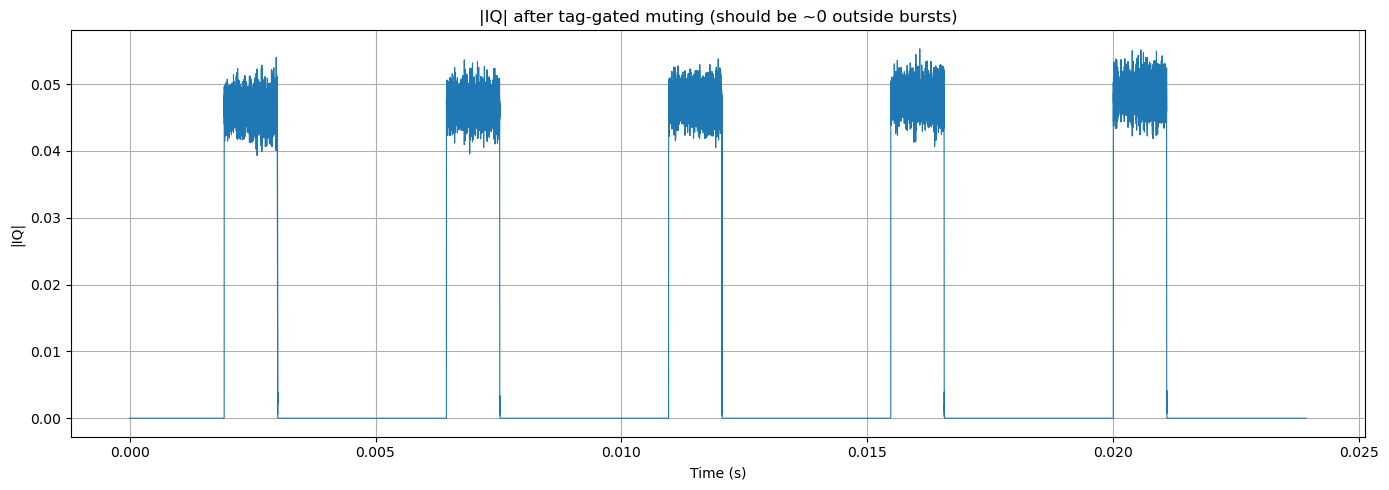

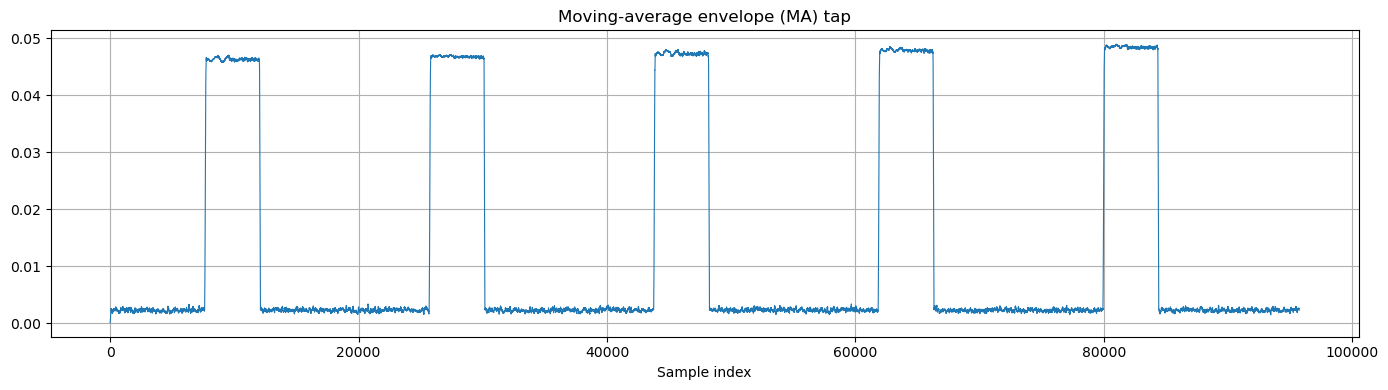

In [2]:
# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000
n_plot = 200_000

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # the tag key you want to drive gating


tap_ma = blocks.vector_sink_f()

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# FIX: short_to_float MULTIPLIES by scale; int16 -> [-1,1) needs 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)

iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# NEW: Tag-gated pass (mute) block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# NEW: apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# capture gated stream
tb.connect(tag_gate, head)
tb.connect(head, vsink)

# tap MA for plotting/debug
tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)

tags = list(vsink.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    # display value in a readable way
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (should be ~0 outside bursts)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(ma_vals[:min(len(ma_vals), n_plot)], linewidth=0.8)
plt.title("Moving-average envelope (MA) tap")
plt.xlabel("Sample index")
plt.grid(True)
plt.tight_layout()
plt.show()


# Pass-Gate applied to demod

Captured: IQ=5000000 complex, disc=5000000, lpf=5000000, clk=311282, bits=311282
Captured 5000000 complex samples
Total tags captured: 80
'burst' tags captured: 80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger90
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger90
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger90


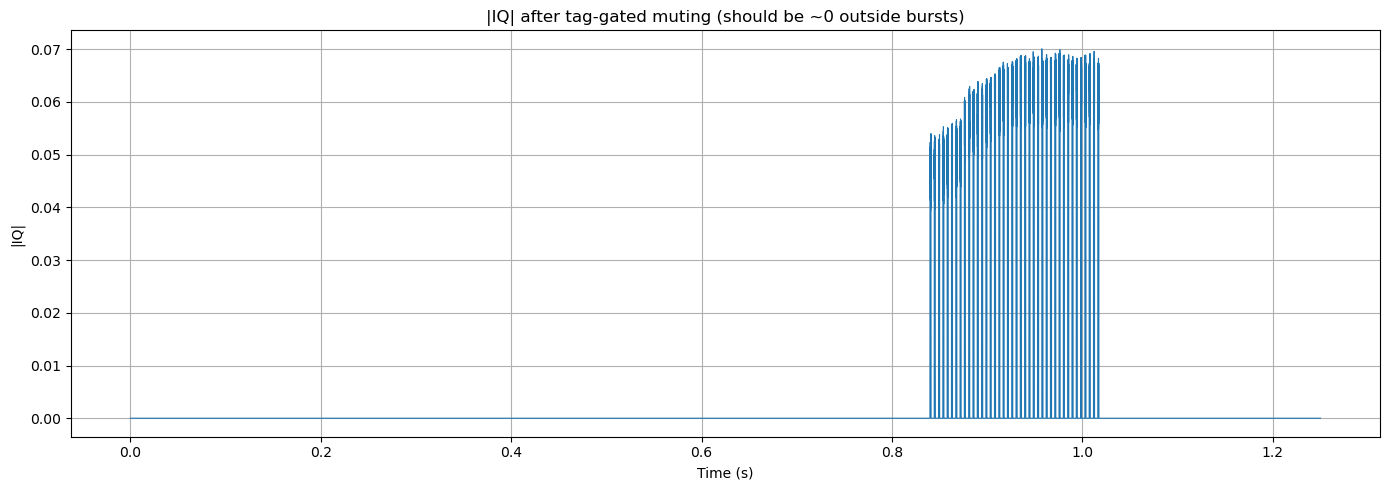

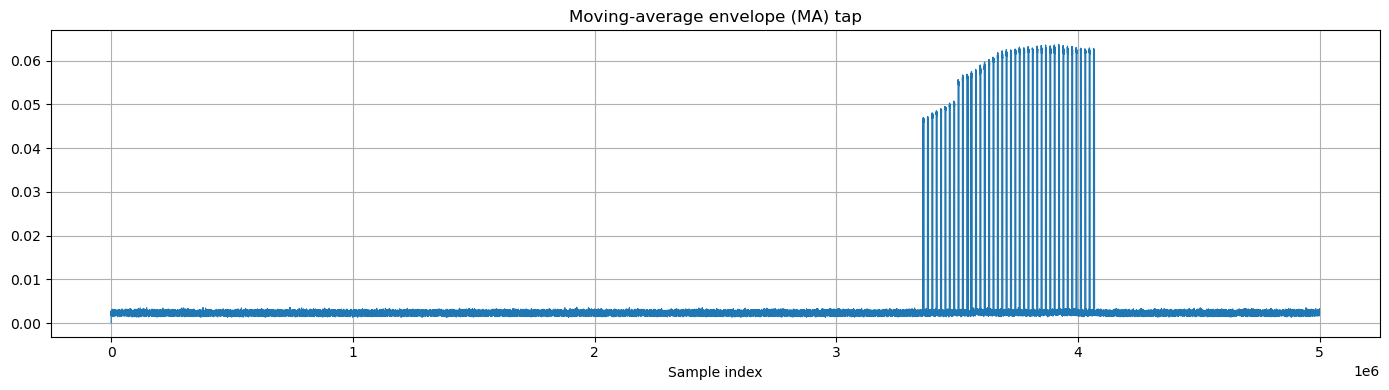

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16
n_plot = 5_000_000 # 500_000 #200_000

# Quad Gain
df = 155_000  # FSK frequency deviation (freq_spacing / 2)
quad_gain = samp_rate / (2*np.pi*df)   # ≈ 4.11

# Use your envelope stats: noise ~0.002-0.003, burst ~0.04
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

lpf_cutoff_hz = 350_000  
lpf_trans_hz  = 100_000

smooth_len = 64  # helps avoid trigger chatter
tag_key = "burst"  # the tag key you want to drive gating


tap_ma = blocks.vector_sink_f()

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_minimal_two_input")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# FIX: short_to_float MULTIPLIES by scale; int16 -> [-1,1) needs 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# Limit capture for plotting + capture tags
head  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink = blocks.vector_sink_c()

# ---- taps (vector sinks) ----
tap_iq   = blocks.vector_sink_c()   # complex IQ after conversion
tap_disc = blocks.vector_sink_f()   # after quadrature demod
tap_lpf  = blocks.vector_sink_f()   # after LPF
tap_clk  = blocks.vector_sink_f()   # after clock recovery
tap_bits = blocks.vector_sink_b()   # after slicer (bytes 0/1)

# 2-FSK discriminator
fsk_disc = analog.quadrature_demod_cf(quad_gain)

# Post-demod LPF
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

# Clock recovery (Mueller & Muller)
clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

# Bit slicer
slicer = digital.binary_slicer_fb()









# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# NEW: Tag-gated pass (mute) block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)



# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# NEW: apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# capture gated stream
tb.connect(tag_gate, head)
tb.connect(head, vsink)

tb.connect(head, tap_iq)
tb.connect(head, fsk_disc)
tb.connect(fsk_disc, tap_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, tap_lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, tap_clk)
tb.connect(clockrec, slicer)
tb.connect(slicer, tap_bits)


# tap MA for plotting/debug
tb.connect(ma, tap_ma)

tb.run()

# -----------------------------
# Pull samples + tags and plot
# -----------------------------
x = np.array(vsink.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)


iq   = np.asarray(tap_iq.data(),   dtype=np.complex64)
disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

print(f"Captured: IQ={iq.size} complex, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")



tags = list(vsink.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Captured {len(x)} complex samples")
print(f"Total tags captured: {len(tags)}")
print(f"'{tag_key}' tags captured: {len(burst_tags)}")
for t in burst_tags[:10]:
    # display value in a readable way
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (should be ~0 outside bursts)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(ma_vals[:min(len(ma_vals), n_plot)], linewidth=0.8)
plt.title("Moving-average envelope (MA) tap")
plt.xlabel("Sample index")
plt.grid(True)
plt.tight_layout()
plt.show()


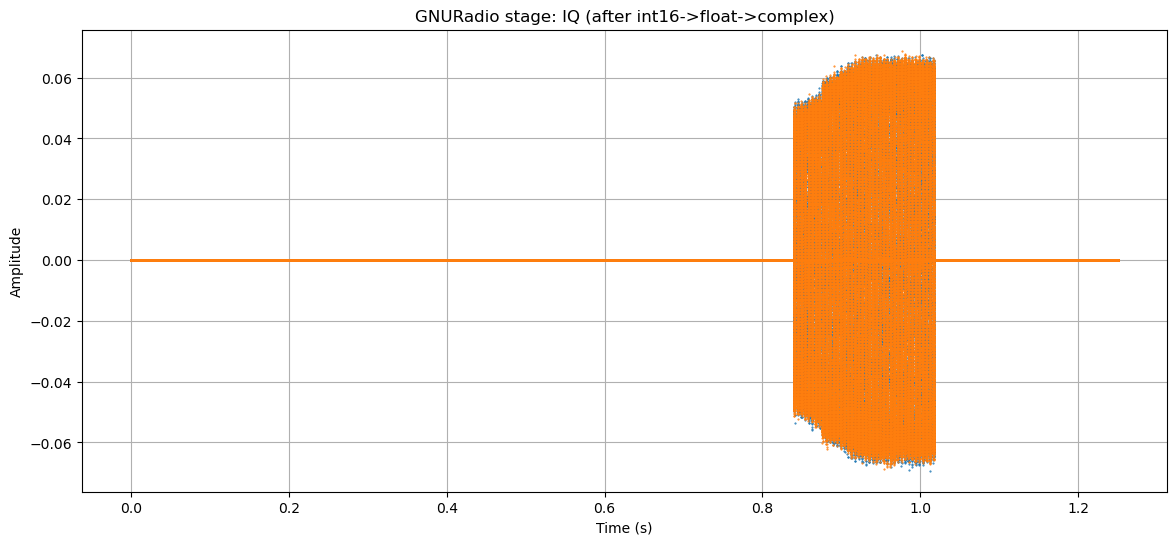

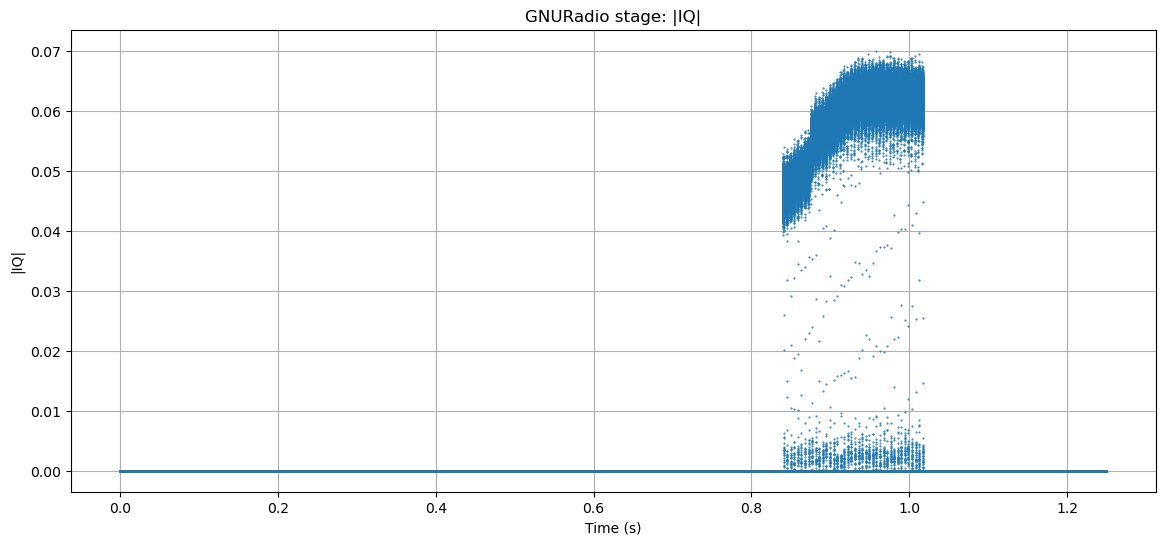

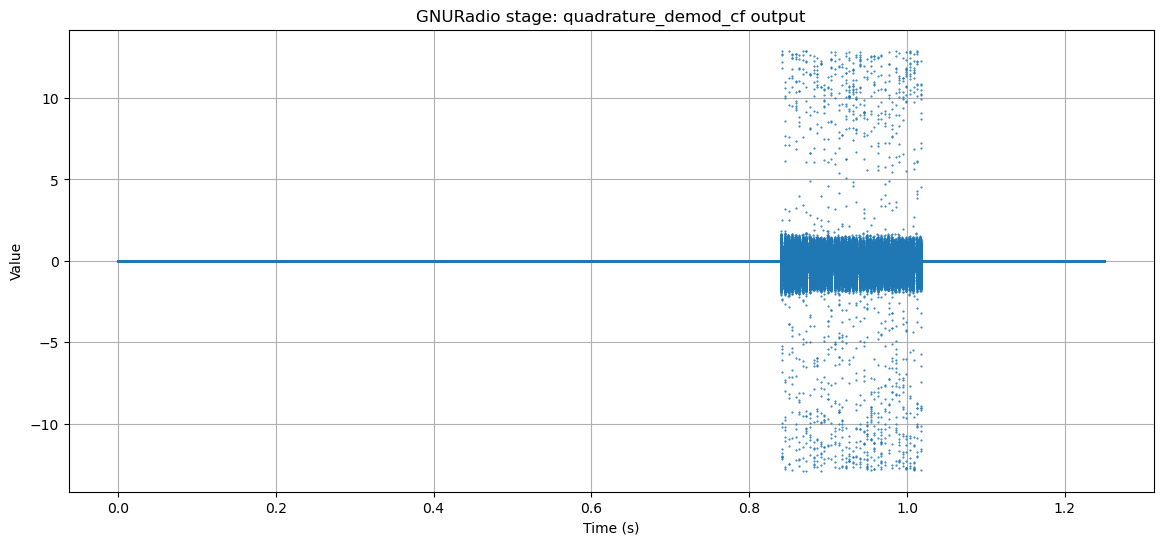

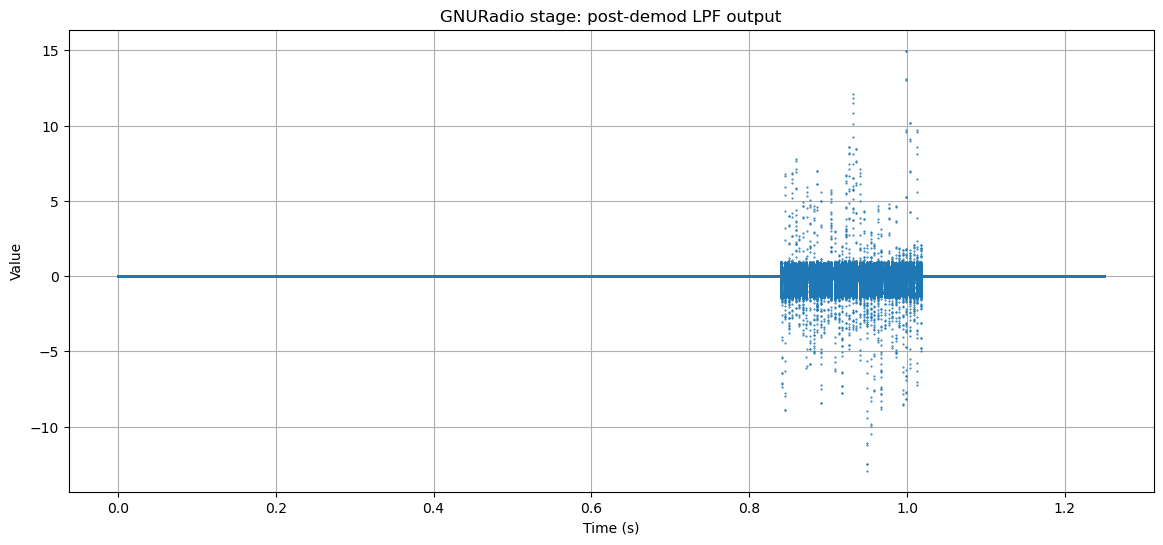

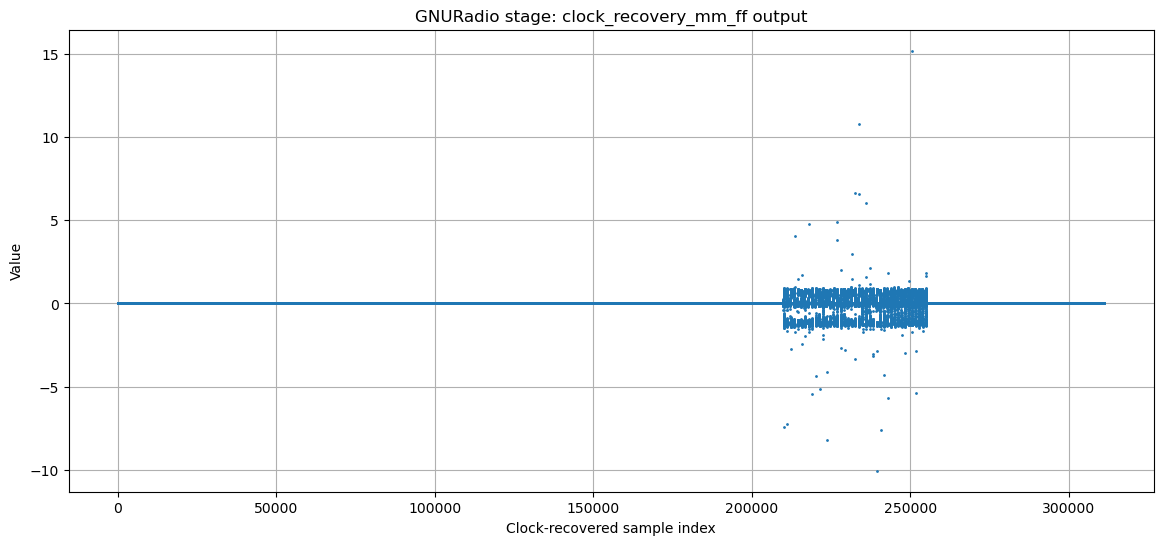

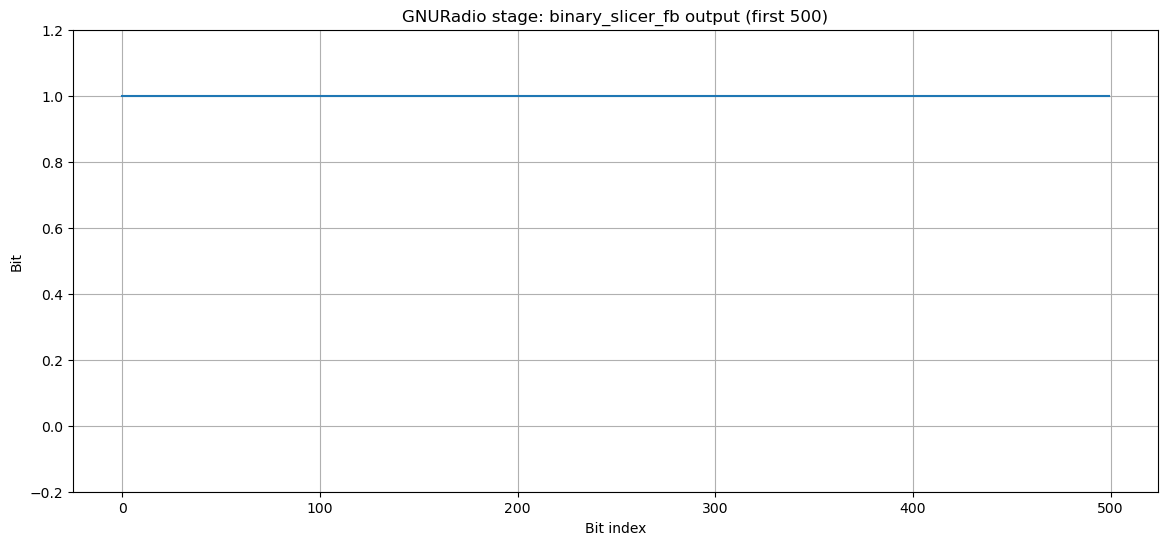

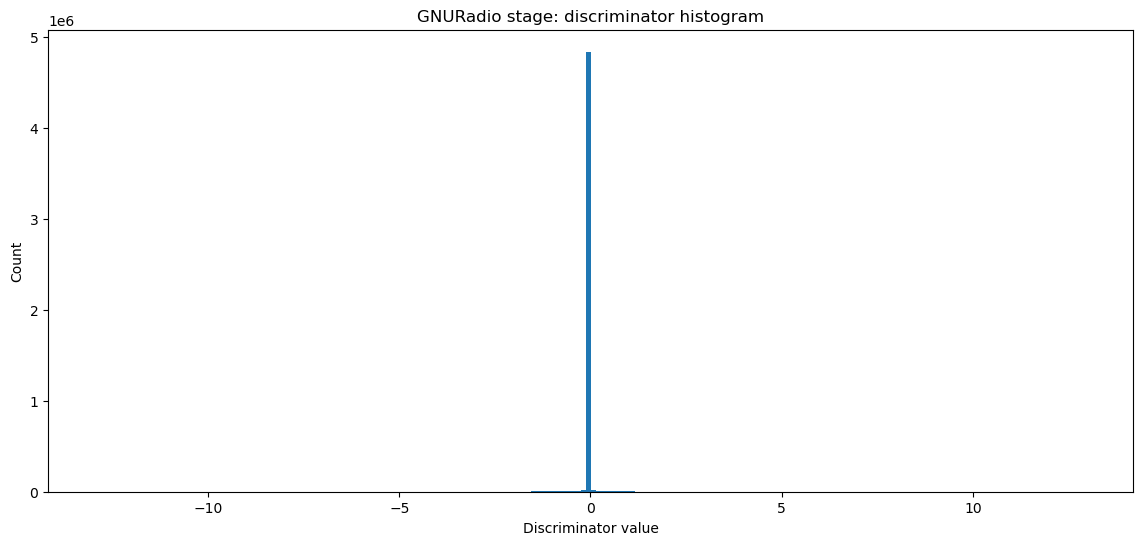

In [12]:
fig_size = (14, 6)
marker_size = 1

t_iq = np.arange(iq.size) / samp_rate
t_f  = np.arange(disc.size) / samp_rate

# 1) IQ (I and Q)
plt.figure(figsize=fig_size)
plt.plot(t_iq, iq.real, '.', markersize=marker_size); 
plt.plot(t_iq, iq.imag, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("GNURadio stage: IQ (after int16->float->complex)")
plt.grid()
plt.show()

# 2) |IQ|
plt.figure(figsize=fig_size)
plt.plot(t_iq, np.abs(iq), '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.title("GNURadio stage: |IQ|")
plt.grid()
plt.show()

# 3) Discriminator output
plt.figure(figsize=fig_size)
plt.plot(t_f, disc, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: quadrature_demod_cf output")
plt.grid()
plt.show()

# 4) LPF output
plt.figure(figsize=fig_size)
plt.plot(np.arange(lpfv.size) / samp_rate, lpfv, '.', markersize=marker_size); 
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title("GNURadio stage: post-demod LPF output")
plt.grid()
plt.show()

# 5) Clock recovery output (index axis; sample rate has changed)
marker_size = 2
plt.figure(figsize=fig_size)
plt.plot(clk, '.', markersize=marker_size); 
plt.xlabel("Clock-recovered sample index")
plt.ylabel("Value")
plt.title("GNURadio stage: clock_recovery_mm_ff output")
plt.grid()
plt.show()

# 6) Bits (first 500)
plt.figure(figsize=fig_size)
m = min(500, bits.size)
plt.step(np.arange(m), bits[:m], where="post", markersize=marker_size); 
plt.ylim(-0.2, 1.2)
plt.xlabel("Bit index")
plt.ylabel("Bit")
plt.title("GNURadio stage: binary_slicer_fb output (first 500)")
plt.grid()
plt.show()

# Optional: histogram of discriminator (often shows two lobes for 2-FSK)
plt.figure(figsize=fig_size)
plt.hist(disc, bins=200)
plt.xlabel("Discriminator value")
plt.ylabel("Count")
plt.title("GNURadio stage: discriminator histogram")
plt.show()

In [13]:
bits.shape

(311282,)

In [14]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
# pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(indices)

[210079 211101 212230 213357 214489 215619 216747 217880 219009 220137
 221265 223521 224651 225784 226916 229191 230318 231447 232578 233711
 234849 237126 238253]


## Remved n_plot from data processing

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"
#iq_file = r"ls-OFF-4M-p6M-03.complex32s"
samp_rate = 4_000_000
samples_per_symbol = 16

tap_bits_file = "out_bits.bin"

# Plot-only limit (ONLY used on plot branch)
n_plot = 5_000_000

# Quad Gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

smooth_len = 64
tag_key = "burst"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tagger_two_branch")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# NOTE: short_to_float MULTIPLIES by scale -> use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# -----------------------------
# Full processing chain (NO head, NO vector sinks)
# -----------------------------
fsk_disc = analog.quadrature_demod_cf(quad_gain)

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

slicer = digital.binary_slicer_fb()

# IMPORTANT: don’t store full-file outputs in RAM
# Write bits to disk (or use null_sink if you only care that it runs)
bits_out = blocks.file_sink(gr.sizeof_char, "out_bits.bin", False)
# If you want float/diagnostic streams, also use file_sink or null_sink:
# disc_out = blocks.file_sink(gr.sizeof_float, "out_disc.f32", False)

# Termination sinks if you don’t need them:
null_c = blocks.null_sink(gr.sizeof_gr_complex)
null_f = blocks.null_sink(gr.sizeof_float)

# -----------------------------
# Plot branch (ONLY place that uses n_plot + vector sinks)
# -----------------------------
head_plot_c = blocks.head(gr.sizeof_gr_complex, n_plot)
# head_plot_c = blocks.head(gr.sizeof_gr_complex)
vsink_plot_c = blocks.vector_sink_c()

tap_ma = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

head_plot_ma   = blocks.head(gr.sizeof_float, n_plot)       # MA is float stream
head_plot_disc = blocks.head(gr.sizeof_float, n_plot)
head_plot_lpf  = blocks.head(gr.sizeof_float, n_plot)
head_plot_clk  = blocks.head(gr.sizeof_float, n_plot)
head_plot_bits = blocks.head(gr.sizeof_char,  n_plot)       # slicer outputs bytes

# head_plot_ma   = blocks.head(gr.sizeof_float)       # MA is float stream
# head_plot_disc = blocks.head(gr.sizeof_float)
# head_plot_lpf  = blocks.head(gr.sizeof_float)
# head_plot_clk  = blocks.head(gr.sizeof_float)
# head_plot_bits = blocks.head(gr.sizeof_char)       # slicer outputs bytes

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))
tb.connect(f2s,  (bt, 1))

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL processing path (unbounded)
# -----------------------------
tb.connect(tag_gate, fsk_disc)
tb.connect(fsk_disc, lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, slicer)
tb.connect(slicer, bits_out)

# (optional) terminate streams you don’t otherwise sink
# tb.connect(tag_gate, null_c)
# tb.connect(fsk_disc, null_f)

# -----------------------------
# PLOT branch (bounded by n_plot)
# -----------------------------
tb.connect(tag_gate, head_plot_c)
tb.connect(head_plot_c, vsink_plot_c)

tb.connect(ma, head_plot_ma)
tb.connect(head_plot_ma, tap_ma)

tb.connect(fsk_disc, head_plot_disc)
tb.connect(head_plot_disc, tap_disc)

tb.connect(lpf, head_plot_lpf)
tb.connect(head_plot_lpf, tap_lpf)

tb.connect(clockrec, head_plot_clk)
tb.connect(head_plot_clk, tap_clk)

tb.connect(slicer, head_plot_bits)
tb.connect(head_plot_bits, tap_bits)

tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x = np.array(vsink_plot_c.data(), dtype=np.complex64)
ma_vals = np.array(tap_ma.data(), dtype=np.float32)

disc = np.asarray(tap_disc.data(), dtype=np.float32)
lpfv = np.asarray(tap_lpf.data(),  dtype=np.float32)
clk  = np.asarray(tap_clk.data(),  dtype=np.float32)
bits = np.asarray(tap_bits.data(), dtype=np.uint8)

bits_out = read_u8(tap_bits_file)


print(f"Plot captured: x={x.size}, ma={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print("Full bits written to: out_bits.bin")

tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)} '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

# t = np.arange(len(x)) / samp_rate

# plt.figure(figsize=(14, 5))
# plt.plot(t, np.abs(x), linewidth=0.8)
# plt.title("|IQ| after tag-gated muting (plot branch only)")
# plt.xlabel("Time (s)")
# plt.ylabel("|IQ|")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) tap (plot branch only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Plot captured: x=5000000, ma=5000000, disc=5000000, lpf=5000000, clk=311273, bits=311273
Full bits written to: out_bits.bin
Plot tags captured: total=80 'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger343
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger343
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger343


In [35]:
bits_out.shape

(311273,)

In [31]:
import numpy as np

arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

29
[210079 211101 212230 213357 214489 215619 216747 217880 219009 220137
 221265 223521 224651 225784 226916 229191 230318 231447 232578 233711
 234849 237126 238253 241622 242738 244968 246081 247192 250520]


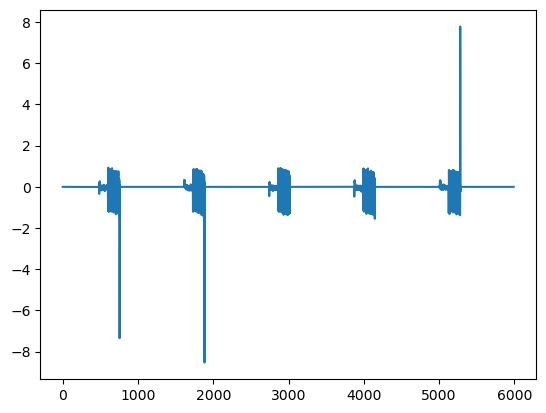

In [26]:
plt.plot(clk)

In [ ]:
# -----------------------------
# Plot branch (ONLY place that uses n_plot + vector sinks)
# -----------------------------
head_plot_c = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

tap_ma = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

head_plot_ma   = blocks.head(gr.sizeof_float, n_plot)       # MA is float stream
head_plot_disc = blocks.head(gr.sizeof_float, n_plot)
head_plot_lpf  = blocks.head(gr.sizeof_float, n_plot)
head_plot_clk  = blocks.head(gr.sizeof_float, n_plot)
head_plot_bits = blocks.head(gr.sizeof_char,  n_plot)       # slicer outputs bytes



### head block stops the full flow graph

Plot captured: IQ=5000000 complex, MA=5000000, disc=5000000, lpf=5000000, clk=313438, bits=313438
Full-file bits written to: out_bits.bin
Plot tags captured: total=80  'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger619
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger619
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger619
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger619
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger619
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger619
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger619
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger619
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger619
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger619


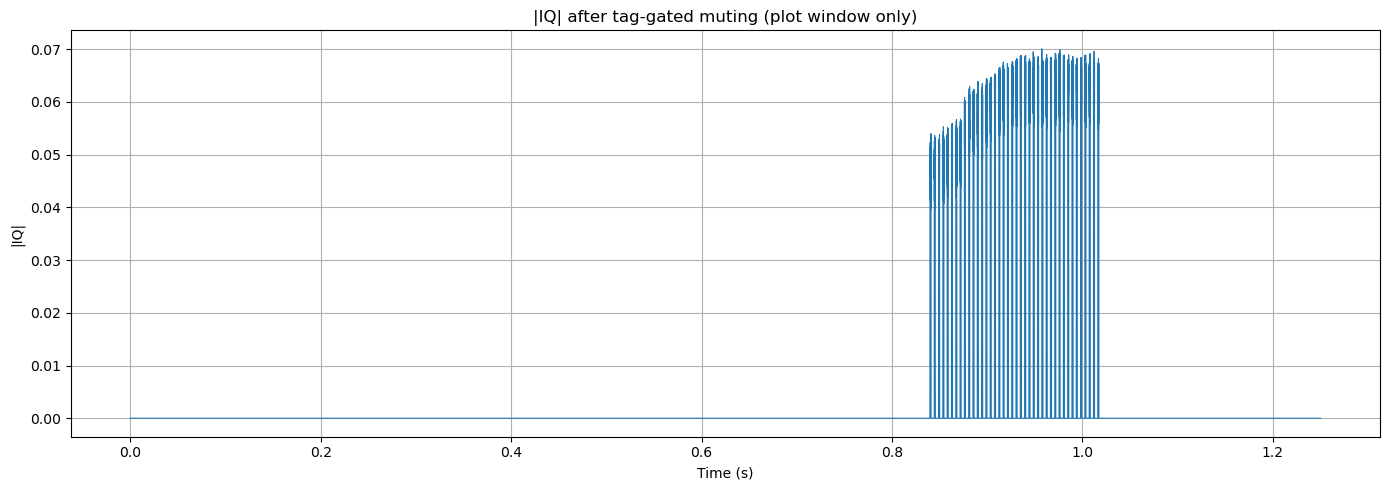

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# Plot-only limit (ONLY used once, to bound plotting RAM)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded ONCE by n_plot on complex stream)
# -----------------------------
head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

# Plot-only re-derive envelope/MA from the *same bounded window*
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
tb.connect(tag_gate, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (process only first n_plot complex samples AFTER tag gating)
# -----------------------------
tb.connect(tag_gate, head_plot_c)

# capture bounded IQ + tags
tb.connect(head_plot_c, vsink_plot_c)

# bounded envelope/MA for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_mag)
tb.connect(plot_mag, plot_ma)
tb.connect(plot_ma, tap_ma)

# bounded demod chain for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_disc)
tb.connect(plot_disc, plot_lpf)
tb.connect(plot_lpf, plot_clockrec)
tb.connect(plot_clockrec, plot_slicer)

# taps (NO extra heads anywhere)
tb.connect(plot_disc, tap_disc)
tb.connect(plot_lpf,  tap_lpf)
tb.connect(plot_clockrec, tap_clk)
tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x      = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals= np.asarray(tap_ma.data(),       dtype=np.float32)
disc   = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv   = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk    = np.asarray(tap_clk.data(),      dtype=np.float32)
bits   = np.asarray(tap_bits.data(),     dtype=np.uint8)

bits_out = read_u8(tap_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (plot window only)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [57]:
bits.shape

(313438,)

In [58]:
bits_out.shape

(311398,)

In [61]:
import numpy as np

arr = bits

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
# pattern_str = "1110001"
pattern_str = "11100010000111101010101001011110111110"
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

35
[210079 211207 212339 213469 214604 215740 216868 217998 219125 220256
 221383 222514 223646 224775 225903 228163 229296 231550 233808 236062
 237195 238323 240583 241716 242737 243863 244993 246123 247255 248386
 249518 251772 252903 254039 255177]


Plot captured: IQ=5000000 complex, MA=5000000, disc=5000000, lpf=5000000, clk=313911, bits=313911
Full-file bits written to: out_bits.bin
Plot tags captured: total=80  'burst'=80
tag: offset=3359293, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3363651, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3377368, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3381725, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3395440, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3399800, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3413513, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3417874, key=burst, value=#f, srcid=burst_tagger538
tag: offset=3431611, key=burst, value=#t, srcid=burst_tagger538
tag: offset=3435973, key=burst, value=#f, srcid=burst_tagger538


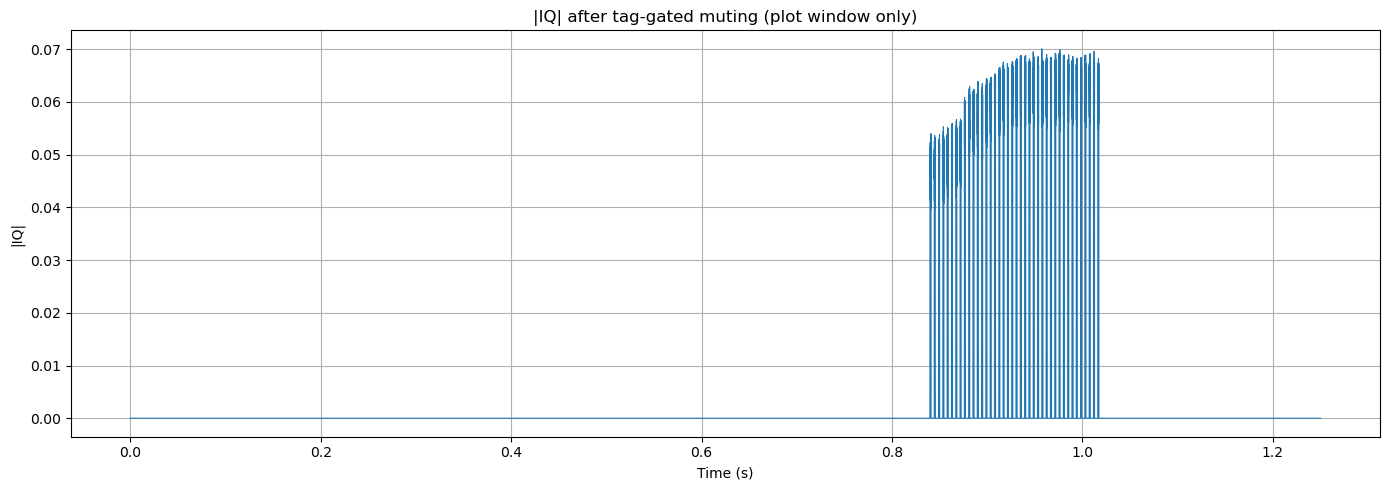

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# Plot-only limit (ONLY for plotting RAM; full chain processes entire file)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot_isolated")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded, and ISOLATED so it won't stop the full chain)
# -----------------------------
# IMPORTANT: isolate the plot branch so head() can't terminate the whole flowgraph
plot_copy = blocks.copy(gr.sizeof_gr_complex)

head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)   # ONLY use of n_plot
vsink_plot_c = blocks.vector_sink_c()

# Plot-only chain (separate instances so plotting doesn't disturb full chain)
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
tb.connect(tag_gate, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (safe: isolated by copy, bounded by head)
# -----------------------------
tb.connect(tag_gate, plot_copy)       # isolate branch from scheduler DONE
tb.connect(plot_copy, head_plot_c)    # bound plot window

# capture bounded IQ + tags
tb.connect(head_plot_c, vsink_plot_c)

# bounded envelope/MA for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_mag)
tb.connect(plot_mag, plot_ma)
tb.connect(plot_ma, tap_ma)

# bounded demod chain for plotting (aligned with bounded IQ)
tb.connect(head_plot_c, plot_disc)
tb.connect(plot_disc, plot_lpf)
tb.connect(plot_lpf, plot_clockrec)
tb.connect(plot_clockrec, plot_slicer)

# taps (NO extra heads anywhere)
tb.connect(plot_disc, tap_disc)
tb.connect(plot_lpf,  tap_lpf)
tb.connect(plot_clockrec, tap_clk)
tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
x       = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals = np.asarray(tap_ma.data(),       dtype=np.float32)
disc    = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv    = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk     = np.asarray(tap_clk.data(),      dtype=np.float32)
bits    = np.asarray(tap_bits.data(),     dtype=np.uint8)


def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)

bits_ = read_u8(tap_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (plot window only)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [46]:
bits.shape

(313911,)

In [47]:
bits_.shape

(313531,)

### Just one stream

Full-file bits written to: out_bits.bin
Tap files written:
  tap_iq_gated.c64 tap_ma.f32 tap_disc.f32 tap_lpf.f32 tap_clk.f32
Plot arrays: IQ=5000000, MA=5000000, disc=5000000, lpf=5000000, clk=4167412


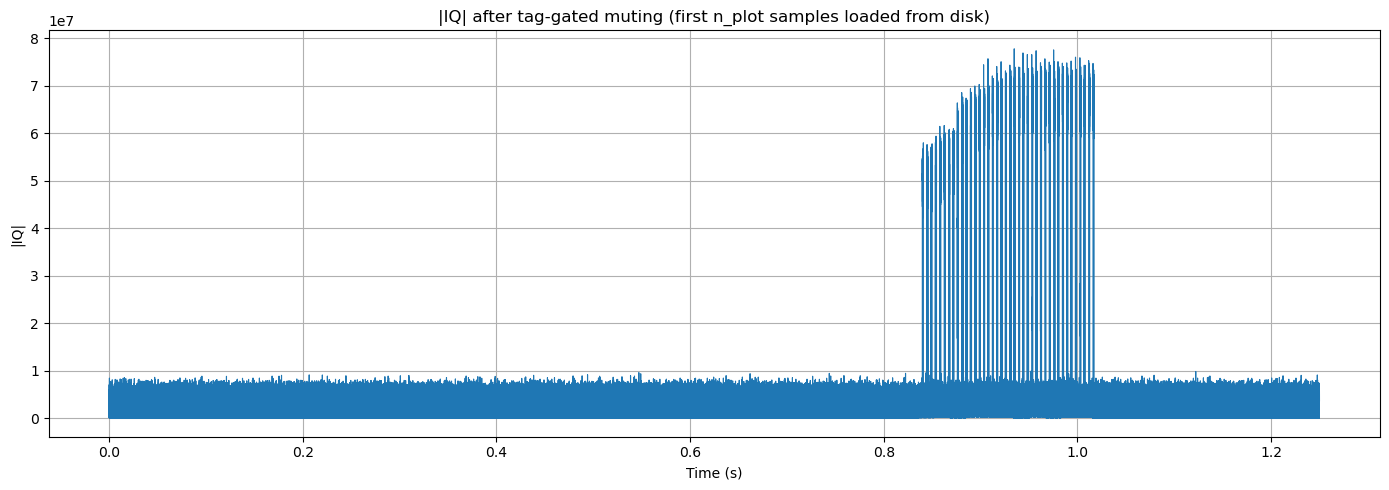

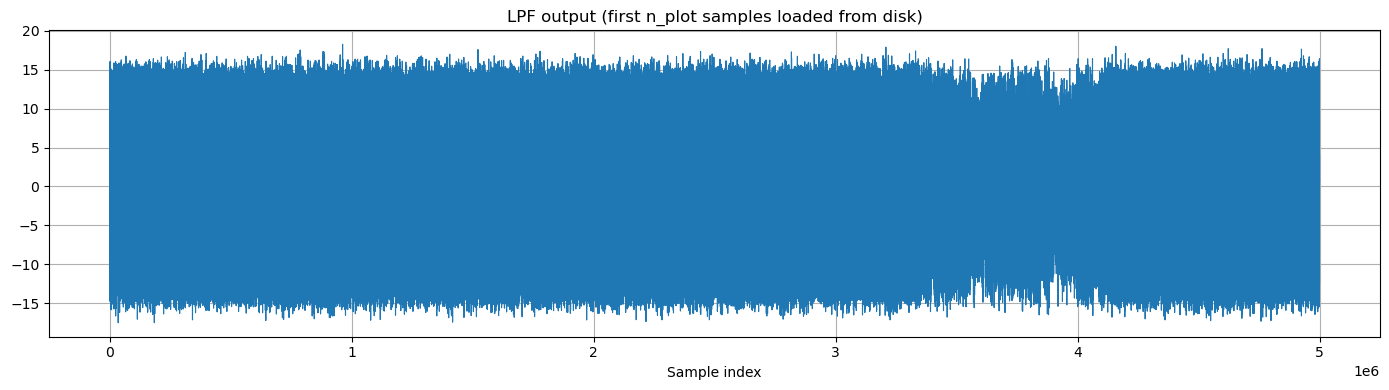

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"   # int16 interleaved I,Q
samp_rate = 4_000_000
samples_per_symbol = 16

# ONLY used for plotting (limits NumPy arrays, not processing)
n_plot = 5_000_000

# 2-FSK discriminator gain
df = 155_000
quad_gain = samp_rate / (2*np.pi*df)

# Envelope gate
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

tag_key = "burst"

# Output files (full processing goes here)
out_bits_file = "out_bits.bin"

# Debug/plot tap files (full length on disk; we only read first n_plot for plotting)
tap_iq_file   = "tap_iq_gated.c64"
tap_ma_file   = "tap_ma.f32"
tap_disc_file = "tap_disc.f32"
tap_lpf_file  = "tap_lpf.f32"
tap_clk_file  = "tap_clk.f32"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("single_stream_full_processing_plot_from_files")

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale => use 1/32768
i_f   = blocks.short_to_float(1, 1.0/32768.0)
q_f   = blocks.short_to_float(1, 1.0/32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-driven gate (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# Demod chain
disc = analog.quadrature_demod_cf(quad_gain)

lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)
lpf = filter.fir_filter_fff(1, lpf_taps)

clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

slicer = digital.binary_slicer_fb()

# -----------------------------
# File sinks for full-length capture (plot later by reading only first n_plot)
# -----------------------------
tap_iq_sink   = blocks.file_sink(gr.sizeof_gr_complex, tap_iq_file, False)
tap_ma_sink   = blocks.file_sink(gr.sizeof_float,      tap_ma_file, False)
tap_disc_sink = blocks.file_sink(gr.sizeof_float,      tap_disc_file, False)
tap_lpf_sink  = blocks.file_sink(gr.sizeof_float,      tap_lpf_file, False)
tap_clk_sink  = blocks.file_sink(gr.sizeof_float,      tap_clk_file, False)

bits_out      = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# (optional) make file output unbuffered-ish for debugging; harmless otherwise
# tap_iq_sink.set_unbuffered(True)
# bits_out.set_unbuffered(True)

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# envelope / trigger
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging
tb.connect(iq_c, (bt, 0))
tb.connect(f2s,  (bt, 1))

# tag-gated muting
tb.connect(bt, tag_gate)

# demod chain (single stream)
tb.connect(tag_gate, disc)
tb.connect(disc, lpf)
tb.connect(lpf, clockrec)
tb.connect(clockrec, slicer)
tb.connect(slicer, bits_out)

# tap-to-disk (does NOT affect scheduler termination)
tb.connect(tag_gate, tap_iq_sink)   # gated IQ
tb.connect(ma,       tap_ma_sink)   # MA envelope (ungated; if you want gated MA, compute MA after tag_gate)
tb.connect(disc,     tap_disc_sink)
tb.connect(lpf,      tap_lpf_sink)
tb.connect(clockrec, tap_clk_sink)

# -----------------------------
# Run full file
# -----------------------------
tb.run()

print(f"Full-file bits written to: {out_bits_file}")
print("Tap files written:")
print(" ", tap_iq_file, tap_ma_file, tap_disc_file, tap_lpf_file, tap_clk_file)

# -----------------------------
# Plot: load ONLY first n_plot items from tap files
# -----------------------------
# IQ: complex64
x = np.fromfile(tap_iq_file, dtype=np.complex64, count=n_plot)

# Floats: float32
ma_vals = np.fromfile(tap_ma_file,   dtype=np.float32, count=n_plot)
disc_v  = np.fromfile(tap_disc_file, dtype=np.float32, count=n_plot)
lpf_v   = np.fromfile(tap_lpf_file,  dtype=np.float32, count=n_plot)
clk_v   = np.fromfile(tap_clk_file,  dtype=np.float32, count=n_plot)

print(f"Plot arrays: IQ={x.size}, MA={ma_vals.size}, disc={disc_v.size}, lpf={lpf_v.size}, clk={clk_v.size}")

t = np.arange(len(x)) / samp_rate

plt.figure(figsize=(14, 5))
plt.plot(t, np.abs(x), linewidth=0.8)
plt.title("|IQ| after tag-gated muting (first n_plot samples loaded from disk)")
plt.xlabel("Time (s)")
plt.ylabel("|IQ|")
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpf_v, linewidth=0.8)
# plt.title("LPF output (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk_v, linewidth=0.8)
# plt.title("Clock recovery output (first n_plot samples loaded from disk)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [50]:
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
bits_ = read_u8(out_bits_file)

In [51]:
bits_.shape

(4167412,)

In [55]:
import numpy as np

arr = bits_

# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)

# Create sliding windows
windows = np.lib.stride_tricks.sliding_window_view(arr, m)

# Compare each window with the pattern
matches = np.all(windows == pattern, axis=1)

# Indices where pattern starts
indices = np.where(matches)[0]

print(len(indices))
print(indices)

92
[ 244262  247618  250930  258631  262021  264248  268626  272060  282282
  287830  288842  610332  612643  618357  619371  621653  622791  624993
  628406  635992  637014  638131  649040  652353  654519  656731  658983
 1021223 1024514 1025646 1027928 1031185 1032321 1036914 1041253 1042378
 1043526 1045806 1050367 1051504 1053741 1059369 1062800 1526412 1533186
 1535447 1537791 1542297 2020289 2022514 2029132 2031412 2033519 2040229
 2041384 2047162 2057305 2061797 2575998 2580463 2606105 2607257 2613987
 2616258 2618484 2620732 3157081 3158229 3161586 3162732 3165032 3169423
 3171618 3177151 3187123 3188267 3598984 3600009 3602231 3604354 3605483
 3608828 3609850 3612070 3616660 3617682 3630758 3632971 3633996 3636306
 3637440 3638561]


In [90]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M-03.complex32s"
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
symbol_rate = 250_000
samples_per_symbol = int(samp_rate/symbol_rate)
print("Samples per symbol =", samples_per_symbol)

# Plot-only limit (ONLY used once, to bound plotting RAM)
n_plot = 10_000

# FSK discriminator gain
df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 16 #32 #64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot")
# tb.set_max_noutput_items(4096)

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded ONCE by n_plot on complex stream)
# -----------------------------
head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

# Plot-only re-derive envelope/MA from the *same bounded window*
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# apply tag-driven gating/muting
tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
tb.connect(tag_gate, full_disc)
# tb.connect(iq_c, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (process only first n_plot complex samples AFTER tag gating)
# -----------------------------
# capture bounded IQ + tags
tb.connect(tag_gate, vsink_plot_c)
if False:
    
    
    # bounded envelope/MA for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_mag)
    tb.connect(plot_mag, plot_ma)
    tb.connect(plot_ma, tap_ma)
    
    # bounded demod chain for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_disc)
    tb.connect(plot_disc, plot_lpf)
    tb.connect(plot_lpf, plot_clockrec)
    tb.connect(plot_clockrec, plot_slicer)
    
    # taps (NO extra heads anywhere)
    tb.connect(plot_disc, tap_disc)
    tb.connect(plot_lpf,  tap_lpf)
    tb.connect(plot_clockrec, tap_clk)
    tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x      = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals= np.asarray(tap_ma.data(),       dtype=np.float32)
disc   = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv   = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk    = np.asarray(tap_clk.data(),      dtype=np.float32)
bits   = np.asarray(tap_bits.data(),     dtype=np.uint8)

bits_out = read_u8(out_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
# tags = list(full_disc.tags())
    
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
print("Numer of bursts =", int(len(burst_tags)/2))
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

# t = np.arange(len(x)) / samp_rate

# plt.figure(figsize=(14, 5))
# plt.plot(t, np.abs(x), linewidth=0.8)
# plt.title("|IQ| after tag-gated muting (plot window only)")
# plt.xlabel("Time (s)")
# plt.ylabel("|IQ|")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Samples per symbol = 16
Plot captured: IQ=54788096 complex, MA=0, disc=0, lpf=0, clk=0, bits=0
Full-file bits written to: out_bits.bin
Plot tags captured: total=720  'burst'=720
Numer of bursts = 360
tag: offset=3359252, key=burst, value=#t, srcid=burst_tagger695
tag: offset=3363633, key=burst, value=#f, srcid=burst_tagger695
tag: offset=3377327, key=burst, value=#t, srcid=burst_tagger695
tag: offset=3381708, key=burst, value=#f, srcid=burst_tagger695
tag: offset=3395400, key=burst, value=#t, srcid=burst_tagger695
tag: offset=3399782, key=burst, value=#f, srcid=burst_tagger695
tag: offset=3413474, key=burst, value=#t, srcid=burst_tagger695
tag: offset=3417856, key=burst, value=#f, srcid=burst_tagger695
tag: offset=3431571, key=burst, value=#t, srcid=burst_tagger695
tag: offset=3435954, key=burst, value=#f, srcid=burst_tagger695


In [85]:
bits.shape

(0,)

In [86]:
bits_out.shape

(3433426,)

In [87]:
import numpy as np

arr = bits
arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

300


In [75]:
import numpy as np

arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

295


In [59]:
print_len = 30
for i in indices[:10]:
    print(arr[i:i+print_len])

[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]
[1 1 1 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 1 0 1 1 1]


In [162]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M-03.complex32s"
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
symbol_rate = 250_000
samples_per_symbol = int(samp_rate/symbol_rate)
print("Samples per symbol =", samples_per_symbol)

# Plot-only limit (ONLY used once, to bound plotting RAM)
n_plot = 10_000

# FSK discriminator gain
df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 16 #32 #64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot")
tb.set_max_noutput_items(4096)

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# turn gatef (float 0/1) into complex (gate + j0)
# zero_f = blocks.constant_source_f(0.0)
# gate_c = blocks.float_to_complex(1)
gate_c = blocks.float_to_complex(1)
# tb.connect(gatef, (gate_c, 0)) 


# multiply IQ by gate (mute outside bursts)
iq_gated = blocks.multiply_cc(1)

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
# tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded ONCE by n_plot on complex stream)
# -----------------------------
head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

# Plot-only re-derive envelope/MA from the *same bounded window*
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# gate float -> complex
tb.connect(gatef, (gate_c, 0))
# tb.connect(zero_f, (gate_c, 1))

# multiply (bt output keeps tags; gate just mutes samples)
tb.connect(bt, (iq_gated, 0))
tb.connect(gate_c, (iq_gated, 1))



# apply tag-driven gating/muting
# tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
# tb.connect(tag_gate, full_disc)
tb.connect(iq_gated, full_disc)
# tb.connect(iq_c, full_disc)
tb.connect(full_disc, full_lpf)
tb.connect(full_lpf, full_clockrec)
tb.connect(full_clockrec, full_slicer)
tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (process only first n_plot complex samples AFTER tag gating)
# -----------------------------
# capture bounded IQ + tags
tb.connect(iq_gated, vsink_plot_c)
# tb.connect(tag_gate, vsink_plot_c)
if False:
    
    
    # bounded envelope/MA for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_mag)
    tb.connect(plot_mag, plot_ma)
    tb.connect(plot_ma, tap_ma)
    
    # bounded demod chain for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_disc)
    tb.connect(plot_disc, plot_lpf)
    tb.connect(plot_lpf, plot_clockrec)
    tb.connect(plot_clockrec, plot_slicer)
    
    # taps (NO extra heads anywhere)
    tb.connect(plot_disc, tap_disc)
    tb.connect(plot_lpf,  tap_lpf)
    tb.connect(plot_clockrec, tap_clk)
    tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x      = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals= np.asarray(tap_ma.data(),       dtype=np.float32)
disc   = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv   = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk    = np.asarray(tap_clk.data(),      dtype=np.float32)
bits   = np.asarray(tap_bits.data(),     dtype=np.uint8)

bits_out = read_u8(out_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
# tags = list(full_disc.tags())
    
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
print("Numer of bursts =", int(len(burst_tags)/2))
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

# t = np.arange(len(x)) / samp_rate

# plt.figure(figsize=(14, 5))
# plt.plot(t, np.abs(x), linewidth=0.8)
# plt.title("|IQ| after tag-gated muting (plot window only)")
# plt.xlabel("Time (s)")
# plt.ylabel("|IQ|")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Samples per symbol = 16
Plot captured: IQ=54788096 complex, MA=0, disc=0, lpf=0, clk=0, bits=0
Full-file bits written to: out_bits.bin
Plot tags captured: total=720  'burst'=720
Numer of bursts = 360
tag: offset=3359252, key=burst, value=#t, srcid=burst_tagger1400
tag: offset=3363633, key=burst, value=#f, srcid=burst_tagger1400
tag: offset=3377327, key=burst, value=#t, srcid=burst_tagger1400
tag: offset=3381708, key=burst, value=#f, srcid=burst_tagger1400
tag: offset=3395400, key=burst, value=#t, srcid=burst_tagger1400
tag: offset=3399782, key=burst, value=#f, srcid=burst_tagger1400
tag: offset=3413474, key=burst, value=#t, srcid=burst_tagger1400
tag: offset=3417856, key=burst, value=#f, srcid=burst_tagger1400
tag: offset=3431571, key=burst, value=#t, srcid=burst_tagger1400
tag: offset=3435954, key=burst, value=#f, srcid=burst_tagger1400


In [163]:
bits.shape

(0,)

In [164]:
bits_out.shape

(3430356,)

In [165]:
import numpy as np

arr = bits
arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

296


In [153]:
0.25 * 0.175 * 0.175

0.007656249999999999

# Fully deterministic Samples per Symbol

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pmt

from gnuradio import gr, blocks, analog, filter, digital
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
# iq_file = r"ls-OFF-4M-p6M-03.complex32s"
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
symbol_rate = 250_000
samples_per_symbol = int(samp_rate/symbol_rate)
print("Samples per symbol =", samples_per_symbol)

# Plot-only limit (ONLY used once, to bound plotting RAM)
n_plot = 10_000

# FSK discriminator gain
df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 16 #32 #64

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000

# Tag key used by burst_tagger and tag-driven gate
tag_key = "burst"

# Output (full-file) bits
out_bits_file = "out_bits.bin"

# -----------------------------
# Flowgraph
# -----------------------------
tb = gr.top_block("burst_tag_gate_full_plus_plot")
tb.set_max_noutput_items(4096)

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

# IMPORTANT: short_to_float MULTIPLIES by scale, so use 1/32768
i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # outputs 0.0 or 1.0

# turn gatef (float 0/1) into complex (gate + j0)
# zero_f = blocks.constant_source_f(0.0)
# gate_c = blocks.float_to_complex(1)
gate_c = blocks.float_to_complex(1)
# tb.connect(gatef, (gate_c, 0)) 


# multiply IQ by gate (mute outside bursts)
iq_gated = blocks.multiply_cc(1)

# Convert gate 0/1 -> trigger short +/-1 (burst_tagger expects short trigger stream)
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

# burst_tagger: tags stream0 based on trigger stream1 (+/-)
bt = blocks.burst_tagger(gr.sizeof_gr_complex)

# Tag-gated pass/mute block driven by burst tags (YOUR custom block)
# tag_gate = burst_tag_gate_cc(tag_key=tag_key)

# LPF taps reused by both chains
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

# -----------------------------
# FULL processing chain (unbounded; no heads, no vector sinks)
# -----------------------------
full_disc = analog.quadrature_demod_cf(quad_gain)
full_lpf  = filter.fir_filter_fff(1, lpf_taps)

full_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

full_slicer = digital.binary_slicer_fb()
sym_decim = blocks.keep_one_in_n(gr.sizeof_float, samples_per_symbol)
bits_out    = blocks.file_sink(gr.sizeof_char, out_bits_file, False)

# -----------------------------
# PLOT branch (bounded ONCE by n_plot on complex stream)
# -----------------------------
head_plot_c  = blocks.head(gr.sizeof_gr_complex, n_plot)
vsink_plot_c = blocks.vector_sink_c()

# Plot-only re-derive envelope/MA from the *same bounded window*
plot_mag = blocks.complex_to_mag(1)
plot_ma  = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)

plot_disc = analog.quadrature_demod_cf(quad_gain)
plot_lpf  = filter.fir_filter_fff(1, lpf_taps)

plot_clockrec = digital.clock_recovery_mm_ff(
    float(samples_per_symbol),
    0.25 * 0.175 * 0.175,
    0.5,
    0.175,
    0.05
)

plot_slicer = digital.binary_slicer_fb()

tap_ma   = blocks.vector_sink_f()
tap_disc = blocks.vector_sink_f()
tap_lpf  = blocks.vector_sink_f()
tap_clk  = blocks.vector_sink_f()
tap_bits = blocks.vector_sink_b()

# -----------------------------
# Connections
# -----------------------------
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

# build trigger from |IQ|
tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

# burst tagging (tags are placed on the complex stream)
tb.connect(iq_c, (bt, 0))   # signal stream
tb.connect(f2s,  (bt, 1))   # trigger stream (+/-)

# gate float -> complex
tb.connect(gatef, (gate_c, 0))
# tb.connect(zero_f, (gate_c, 1))

# multiply (bt output keeps tags; gate just mutes samples)
tb.connect(bt, (iq_gated, 0))
tb.connect(gate_c, (iq_gated, 1))



# apply tag-driven gating/muting
# tb.connect(bt, tag_gate)

# -----------------------------
# FULL chain (process whole file)
# -----------------------------
# tb.connect(tag_gate, full_disc)
tb.connect(iq_gated, full_disc)
# tb.connect(iq_c, full_disc)
tb.connect(full_disc, full_lpf)
# tb.connect(full_lpf, full_clockrec)
# tb.connect(full_clockrec, full_slicer)

tb.connect(full_lpf, sym_decim)
tb.connect(sym_decim, full_slicer)

tb.connect(full_slicer, bits_out)

# -----------------------------
# PLOT chain (process only first n_plot complex samples AFTER tag gating)
# -----------------------------
# capture bounded IQ + tags
tb.connect(iq_gated, vsink_plot_c)
# tb.connect(tag_gate, vsink_plot_c)
if False:
    
    
    # bounded envelope/MA for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_mag)
    tb.connect(plot_mag, plot_ma)
    tb.connect(plot_ma, tap_ma)
    
    # bounded demod chain for plotting (aligned with bounded IQ)
    tb.connect(tag_gate, plot_disc)
    tb.connect(plot_disc, plot_lpf)
    tb.connect(plot_lpf, plot_clockrec)
    tb.connect(plot_clockrec, plot_slicer)
    
    # taps (NO extra heads anywhere)
    tb.connect(plot_disc, tap_disc)
    tb.connect(plot_lpf,  tap_lpf)
    tb.connect(plot_clockrec, tap_clk)
    tb.connect(plot_slicer, tap_bits)

# -----------------------------
# Run
# -----------------------------
tb.run()

# -----------------------------
# Pull plot samples + tags and plot
# -----------------------------
def read_u8(path):
    return np.fromfile(path, dtype=np.uint8)
    
x      = np.asarray(vsink_plot_c.data(), dtype=np.complex64)
ma_vals= np.asarray(tap_ma.data(),       dtype=np.float32)
disc   = np.asarray(tap_disc.data(),     dtype=np.float32)
lpfv   = np.asarray(tap_lpf.data(),      dtype=np.float32)
clk    = np.asarray(tap_clk.data(),      dtype=np.float32)
bits   = np.asarray(tap_bits.data(),     dtype=np.uint8)

bits_out = read_u8(out_bits_file)

print(f"Plot captured: IQ={x.size} complex, MA={ma_vals.size}, disc={disc.size}, lpf={lpfv.size}, clk={clk.size}, bits={bits.size}")
print(f"Full-file bits written to: {out_bits_file}")

# tags captured on the bounded IQ sink
tags = list(vsink_plot_c.tags())
# tags = list(full_disc.tags())
    
burst_tags = [t for t in tags if pmt.equal(t.key, pmt.intern(tag_key))]

print(f"Plot tags captured: total={len(tags)}  '{tag_key}'={len(burst_tags)}")
print("Numer of bursts =", int(len(burst_tags)/2))
for t in burst_tags[:10]:
    try:
        v_str = pmt.write_string(t.value)
    except Exception:
        v_str = str(t.value)
    print(f"tag: offset={t.offset}, key={pmt.symbol_to_string(t.key)}, value={v_str}, srcid={t.srcid}")

# t = np.arange(len(x)) / samp_rate

# plt.figure(figsize=(14, 5))
# plt.plot(t, np.abs(x), linewidth=0.8)
# plt.title("|IQ| after tag-gated muting (plot window only)")
# plt.xlabel("Time (s)")
# plt.ylabel("|IQ|")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(ma_vals, linewidth=0.8)
# plt.title("Moving-average envelope (MA) (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(lpfv, linewidth=0.8)
# plt.title("LPF output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 4))
# plt.plot(clk, linewidth=0.8)
# plt.title("Clock recovery output (plot window only)")
# plt.xlabel("Sample index")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Samples per symbol = 16
Plot captured: IQ=54788096 complex, MA=0, disc=0, lpf=0, clk=0, bits=0
Full-file bits written to: out_bits.bin
Plot tags captured: total=720  'burst'=720
Numer of bursts = 360
tag: offset=3359252, key=burst, value=#t, srcid=burst_tagger1003
tag: offset=3363633, key=burst, value=#f, srcid=burst_tagger1003
tag: offset=3377327, key=burst, value=#t, srcid=burst_tagger1003
tag: offset=3381708, key=burst, value=#f, srcid=burst_tagger1003
tag: offset=3395400, key=burst, value=#t, srcid=burst_tagger1003
tag: offset=3399782, key=burst, value=#f, srcid=burst_tagger1003
tag: offset=3413474, key=burst, value=#t, srcid=burst_tagger1003
tag: offset=3417856, key=burst, value=#f, srcid=burst_tagger1003
tag: offset=3431571, key=burst, value=#t, srcid=burst_tagger1003
tag: offset=3435954, key=burst, value=#f, srcid=burst_tagger1003


In [110]:
bits.shape

(0,)

In [111]:
bits_out.shape

(3424256,)

In [114]:
import numpy as np

arr = bits
arr = bits_out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

258


# Use PDUs (Protocol Data Unit)

In [173]:
import numpy as np
import pmt
from gnuradio import gr, blocks, analog, filter
from gnuradio.filter import firdes

# Window constant varies by version
try:
    from gnuradio.fft import window
    WIN = window.WIN_HAMMING
except Exception:
    WIN = getattr(firdes, "WIN_HAMMING", None)
    if WIN is None:
        raise RuntimeError("Can't find Hamming window constant in this GNU Radio build.")

# -----------------------------
# PARAMETERS
# -----------------------------
iq_file = r"ls-OFF-4M-p6M-02.complex32s"     # int16 interleaved I,Q
samp_rate = 4_000_000
symbol_rate = 250_000
sps = int(samp_rate / symbol_rate)          # 16
print("Samples per symbol =", sps)

# FSK discriminator gain
df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

# Gate from envelope
gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 16

# Post-demod LPF
lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

tag_key = "burst"
out_bits_file = "out_bits.bin"

# -----------------------------
# A small Python block: stream (complex + burst tags) -> PDU per burst
# -----------------------------
class burst_tags_to_pdu_cc(gr.sync_block):
    """
    Collects complex samples between burst start/end tags and emits a PDU:
      msg = (meta_dict, c32_vector)

    Assumptions:
      - burst_tagger emits tags with key=tag_key, value PMT_T (start) and PMT_F (end)
      - if your build uses different values, tweak is_start/is_end below.
    """
    def __init__(self, tag_key="burst", max_burst_items=5_000_000):
        gr.sync_block.__init__(
            self,
            name="burst_tags_to_pdu_cc",
            in_sig=[np.complex64],
            out_sig=None
        )
        self.message_port_register_out(pmt.intern("pdus"))
        self._k = pmt.intern(tag_key)
        self._buf = []
        self._in_burst = False
        self._start_abs = None
        self._max = int(max_burst_items)

    def _is_start(self, v):
        # Common for burst_tagger: PMT_T=start, PMT_F=end
        return pmt.is_bool(v) and pmt.to_bool(v) is True

    def _is_end(self, v):
        return pmt.is_bool(v) and pmt.to_bool(v) is False

    def work(self, input_items, output_items):
        x = input_items[0]
        n = len(x)
        nread = self.nitems_read(0)

        tags = self.get_tags_in_range(0, nread, nread + n)
        tags.sort(key=lambda t: t.offset)

        idx = 0
        for t in tags:
            if not pmt.equal(t.key, self._k):
                continue
            rel = int(t.offset - nread)
            rel = max(0, min(n, rel))

            # append samples up to the tag under current state
            if rel > idx:
                if self._in_burst:
                    self._buf.append(x[idx:rel].copy())
                    if sum(len(b) for b in self._buf) > self._max:
                        # safety: drop overly large burst
                        self._buf = []
                        self._in_burst = False
                        self._start_abs = None
                idx = rel

            # handle the tag
            if self._is_start(t.value):
                self._in_burst = True
                self._start_abs = int(t.offset)
                self._buf = []  # start a fresh burst buffer
            elif self._is_end(t.value):
                if self._in_burst:
                    # close the burst at this point
                    burst = np.concatenate(self._buf) if self._buf else np.empty(0, np.complex64)
                    meta = pmt.make_dict()
                    meta = pmt.dict_add(meta, pmt.intern("start_offset"), pmt.from_long(self._start_abs))
                    meta = pmt.dict_add(meta, pmt.intern("nitems"), pmt.from_long(int(burst.size)))

                    vec = pmt.init_c32vector(int(burst.size), burst.astype(np.complex64))
                    self.message_port_pub(pmt.intern("pdus"), pmt.cons(meta, vec))

                self._in_burst = False
                self._start_abs = None
                self._buf = []

        # trailing samples after last tag
        if idx < n and self._in_burst:
            self._buf.append(x[idx:].copy())
            if sum(len(b) for b in self._buf) > self._max:
                self._buf = []
                self._in_burst = False
                self._start_abs = None

        return n

class pdu_collector(gr.basic_block):
    def __init__(self, callback):
        gr.basic_block.__init__(self, name="pdu_collector", in_sig=None, out_sig=None)
        self._cb = callback
        self.message_port_register_in(pmt.intern("in"))
        # IMPORTANT: handler is a method of THIS instance
        self.set_msg_handler(pmt.intern("in"), self.handle_msg)

    def handle_msg(self, msg):
        self._cb(msg)


# -----------------------------
# Per-burst deterministic demod/slice (numpy)
# -----------------------------
def quad_demod(xc: np.ndarray, gain: float) -> np.ndarray:
    # angle difference: imag(conj(x[n-1])*x[n]) approximates phase increment
    z = xc[1:] * np.conj(xc[:-1])
    return gain * np.angle(z).astype(np.float32)

def fir_filter(x: np.ndarray, taps: np.ndarray) -> np.ndarray:
    return np.convolve(x, taps.astype(np.float32), mode="same").astype(np.float32)

def pick_best_phase_and_slice(y: np.ndarray, sps: int) -> np.ndarray:
    # choose phase 0..sps-1 that maximizes eye opening (deterministic)
    best_k = 0
    best_score = -1e30
    for k in range(sps):
        s = y[k::sps]
        if s.size < 10:
            continue
        s = s - np.median(s)
        score = float(np.mean(np.abs(s)) - 0.2*np.std(np.abs(s)))
        if score > best_score:
            best_score = score
            best_k = k
    sym = y[best_k::sps]
    bits = (sym > 0).astype(np.uint8)
    return bits

# -----------------------------
# Flowgraph: stream front-end only (file -> burst tags -> PDUs)
# -----------------------------
tb = gr.top_block("burst_to_pdu")
tb.set_max_noutput_items(4096)

# Source: int16 I,Q
src   = blocks.file_source(gr.sizeof_short, iq_file, False)
deint = blocks.deinterleave(gr.sizeof_short)

i_f   = blocks.short_to_float(1, 32768.0)
q_f   = blocks.short_to_float(1, 32768.0)
iq_c  = blocks.float_to_complex(1)

# magnitude -> smoothed -> hysteresis gate (0/1 float)
mag   = blocks.complex_to_mag(1)
ma    = blocks.moving_average_ff(smooth_len, 1.0/smooth_len, 4000)
gatef = blocks.threshold_ff(gate_lo, gate_hi, gate_initial)  # 0/1

# trigger for burst_tagger: 0/1 -> +/-1 short
addm  = blocks.add_const_ff(-0.5)
mul2  = blocks.multiply_const_ff(2.0)
f2s   = blocks.float_to_short(1, 1.0)

burst_tagger = blocks.burst_tagger(gr.sizeof_gr_complex)

# Stream -> PDUs
burst2pdu = burst_tags_to_pdu_cc(tag_key=tag_key)

# Connections
tb.connect(src, deint)
tb.connect((deint, 0), i_f)
tb.connect((deint, 1), q_f)
tb.connect(i_f, (iq_c, 0))
tb.connect(q_f, (iq_c, 1))

tb.connect(iq_c, mag)
tb.connect(mag, ma)
tb.connect(ma, gatef)
tb.connect(gatef, addm)
tb.connect(addm, mul2)
tb.connect(mul2, f2s)

tb.connect(iq_c, (burst_tagger, 0))
tb.connect(f2s,  (burst_tagger, 1))

tb.connect(burst_tagger, burst2pdu)

# -----------------------------
# Collect PDUs during run
# -----------------------------
pdus = []

def on_pdu(msg_pmt):
    meta = pmt.car(msg_pmt)
    vec  = pmt.cdr(msg_pmt)
    start = pmt.to_long(pmt.dict_ref(meta, pmt.intern("start_offset"), pmt.from_long(-1)))
    burst = np.array(pmt.c32vector_elements(vec), dtype=np.complex64)
    pdus.append((start, burst))

collector = pdu_collector(on_pdu)
tb.msg_connect(burst2pdu, "pdus", collector, "in")

tb.run()

print(f"Captured bursts (PDUs): {len(pdus)}")

# -----------------------------
# Per-burst demod + deterministic timing (phase-pick) + slice + write bits
# -----------------------------
taps_np = np.array(lpf_taps, dtype=np.float32)

all_bits = []
for start, burst in sorted(pdus, key=lambda t: t[0]):
    if burst.size < (sps * 8):
        continue

    # quadrature demod + LPF
    d = quad_demod(burst, quad_gain)
    y = fir_filter(d, taps_np)

    # deterministic sample-phase selection + slicing
    bits = pick_best_phase_and_slice(y, sps)
    all_bits.append(bits)

if all_bits:
    out = np.concatenate(all_bits).astype(np.uint8)
else:
    out = np.empty(0, np.uint8)

out.tofile(out_bits_file)
print(f"Wrote {out.size} bits to {out_bits_file}")


Samples per symbol = 16
Captured bursts (PDUs): 360
Wrote 87235 bits to out_bits.bin


In [174]:
out.shape

(87235,)

In [175]:
import numpy as np

arr = out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

320


# NumPy Only Solution

## Performance Profiling and NUMBA JIT Compiler

In [1]:
import time

class Timer(object):
    def __init__(self, name=None, enabled=True):
        self.name = name
        self.enabled = enabled

    def __enter__(self):
        if self.enabled:
            self.tstart = time.time()

    def __exit__(self, type, value, traceback):
        if self.enabled:
            if self.name:
                print('[%s]' % self.name,)
            print('Elapsed: %s' % (time.time() - self.tstart))

In [2]:
import numpy as np

# -----------------------------
# Helpers
# -----------------------------
def read_iq_int16_interleaved(path: str) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.int16)
    if raw.size % 2:
        raw = raw[:-1]
    iq = raw.reshape(-1, 2).astype(np.float32) / 32768.0
    x = iq[:, 0] + 1j * iq[:, 1]
    return x.astype(np.complex64)

def moving_average(x: np.ndarray, n: int) -> np.ndarray:
    # Simple, deterministic MA; same “feel” as GR moving_average_ff
    if n <= 1:
        return x
    kernel = np.ones(n, dtype=np.float32) / n
    return np.convolve(x, kernel, mode="same").astype(np.float32)


# hysteresis_gate is the performance bottleneck 
# => use JIT compiler
# 170 x Speedup compared to Python loop
# def hysteresis_gate(x: np.ndarray, lo: float, hi: float, initial: int = 0) -> np.ndarray:
#     """
#     Returns 0/1 gate with hysteresis:
#       - goes 1 when x >= hi
#       - goes 0 when x <= lo
#       - holds state in between
#     """
#     g = np.zeros_like(x, dtype=np.uint8)
#     state = 1 if initial else 0
#     for i, v in enumerate(x):
#         if state == 0 and v >= hi:
#             state = 1
#         elif state == 1 and v <= lo:
#             state = 0
#         g[i] = state
#     return g

from numba import njit
@njit(nogil=True, cache=True)
def hysteresis_gate(x, lo, hi, initial=0):
    g = np.empty(x.shape[0], dtype=np.uint8)
    state = 1 if initial else 0
    for i in range(x.shape[0]):
        v = x[i]
        if state == 0 and v >= hi:
            state = 1
        elif state == 1 and v <= lo:
            state = 0
        g[i] = state
    return g

def gate_to_bursts(g: np.ndarray) -> list[tuple[int, int]]:
    """
    Convert 0/1 gate to list of (start, end) sample indices, end exclusive.
    """
    # Rising edges: 0->1 ; Falling edges: 1->0
    dg = np.diff(g.astype(np.int8), prepend=g[0])
    starts = np.where(dg == 1)[0]
    ends   = np.where(dg == -1)[0]
    # starts += 500
    # ends -= 400

    # Handle if starts with 1
    if g[0] == 1 and (len(starts) == 0 or starts[0] != 0):
        starts = np.r_[0, starts]

    # Handle if ends with 1
    if g[-1] == 1:
        ends = np.r_[ends, len(g)]

    # Pair up
    n = min(len(starts), len(ends))
    bursts = [(int(starts[i]), int(ends[i])) for i in range(n) if ends[i] > starts[i]]
    return bursts

def design_lowpass_fir(fs: float, cutoff_hz: float, trans_hz: float) -> np.ndarray:
    """
    Simple windowed-sinc FIR lowpass (Hamming).
    Not identical to firdes.low_pass, but close enough for a clean LPF.
    """
    # Rule of thumb for length from transition width:
    # narrower transition -> longer filter
    # Ensure odd length
    N = int(np.ceil(4.0 * fs / max(trans_hz, 1.0)))  # “4” is a decent heuristic
    N = max(N, 33)
    if N % 2 == 0:
        N += 1

    n = np.arange(N) - (N - 1) / 2
    fc = cutoff_hz / fs  # normalized (cycles/sample), 0..0.5
    # ideal LPF impulse response: 2*fc*sinc(2*fc*n)
    h = 2 * fc * np.sinc(2 * fc * n)
    w = np.hamming(N)
    h = (h * w).astype(np.float32)
    h /= np.sum(h)
    return h

def quad_demod(x: np.ndarray, gain: float) -> np.ndarray:
    """
    Quadrature FM demod: gain * angle(x[n]*conj(x[n-1]))
    """
    z = x[1:] * np.conj(x[:-1])
    y = gain * np.angle(z)
    return y.astype(np.float32)

from numba import njit
@njit(nogil=True, cache=True)
def pick_best_phase_and_slice(y: np.ndarray, sps: int) -> np.ndarray:
    """
    Deterministic phase pick: choose k in [0..sps-1] that maximizes “eye opening”
    then slice (y > 0).
    """
    best_k = 0
    best_score = -1e30
    for k in range(sps):
        s = y[k::sps]
        if s.size < 20:
            continue
        s = s - np.median(s)
        score = float(np.mean(np.abs(s)) - 0.2 * np.std(np.abs(s)))
        if score > best_score:
            best_score = score
            best_k = k

    sym = y[best_k::sps]
    bits = (sym > 0).astype(np.uint8)
    return bits

In [317]:
# -----------------------------
# PARAMETERS (match your GR ones)
# -----------------------------
# iq_file = "ls-OFF-4M-p6M.complex32s" 
# iq_file = "ls-OFF-4M-p6M-02.complex32s" 
# iq_file = "ls-OFF-4M-p6M-03.complex32s"
iq_file = "ls-b1-short-press-2p405G-4M-1M.complex32s"
# iq_file = "ls-b1-short-press-2p450G-4M-1M.complex32s"
samp_rate = 4_000_000
symbol_rate = 250_000
sps = int(samp_rate / symbol_rate)      # 16

df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 8 #16

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000  # used only to pick FIR length (roughly)

out_bits_file = "out_bits.bin"

# Burst filtering / cleanup
min_burst_samps = int(0.0005 * samp_rate)  # 0.5 ms minimum burst length (tune)
pad_samps = int(0.0001 * samp_rate)        # 0.1 ms pad around bursts (tune)

# Performance Profiling
profiling_enabled = False

# -----------------------------
# MAIN
# -----------------------------
with Timer("x", profiling_enabled):
    x = read_iq_int16_interleaved(iq_file)
print("Loaded IQ samples:", x.size)

# Pass A: burst detection
with Timer("mag", profiling_enabled):
    mag = np.abs(x).astype(np.float32)
with Timer("ma", profiling_enabled):
    ma = moving_average(mag, smooth_len)
with Timer("gate", profiling_enabled):
    gate = hysteresis_gate(ma, gate_lo, gate_hi, gate_initial)
with Timer("bursts", profiling_enabled):
    bursts = gate_to_bursts(gate)

# cleanup: pad and min length
with Timer("clean", profiling_enabled):
    clean = []
    for a, b in bursts:
        a2 = max(0, a - pad_samps)
        b2 = min(x.size, b + pad_samps)
        if (b2 - a2) >= min_burst_samps:
            clean.append((a2, b2))

print(f"Detected bursts: {len(bursts)}  after cleanup: {len(clean)}")
if clean[:5]:
    print("First bursts (samples):", clean[:5])

# Pass B: per-burst decode
taps = design_lowpass_fir(samp_rate, lpf_cutoff_hz, lpf_trans_hz)

with Timer("all_bits", profiling_enabled):
    all_bits = []
    for i, (a, b) in enumerate(clean):
        xb = x[a:b]
        if xb.size < (sps * 8):
            continue
    
        d = quad_demod(xb, quad_gain)            # length = len(xb)-1
        y = np.convolve(d, taps, mode="same")    # LPF
        bits = pick_best_phase_and_slice(y, sps)
    
        all_bits.append(bits)

out = np.concatenate(all_bits).astype(np.uint8) if all_bits else np.empty(0, np.uint8)
out.tofile(out_bits_file)

print(f"Wrote {out.size} bits to {out_bits_file}")

Loaded IQ samples: 79364096
Detected bursts: 560  after cleanup: 560
First bursts (samples): [(7188574, 7193797), (7206660, 7211883), (7224746, 7229969), (7242830, 7248053), (7260912, 7266135)]
Wrote 183103 bits to out_bits.bin


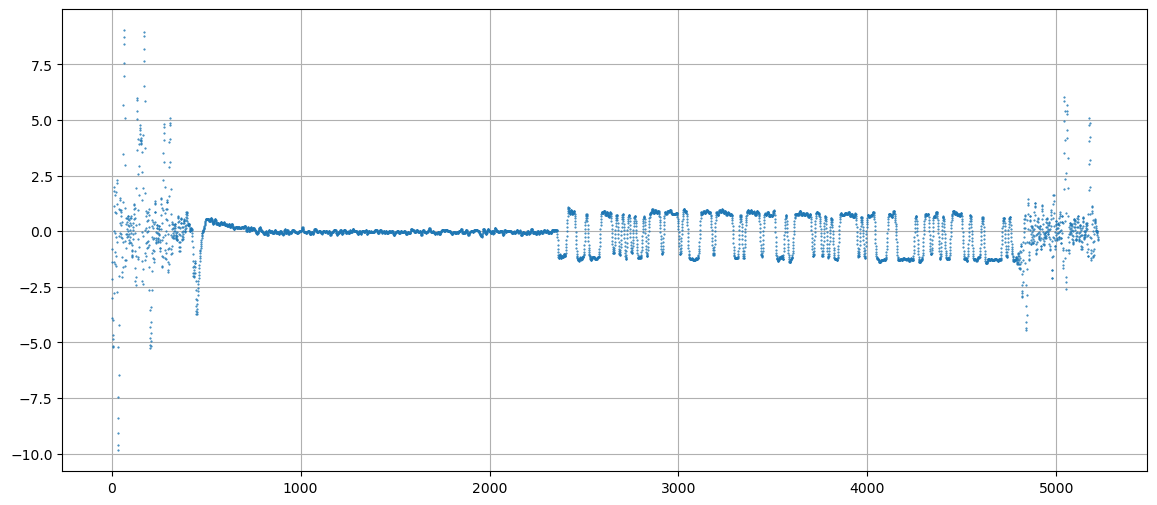

In [318]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
# plt.plot(mag[clean[0][0]:clean[0][1]])
# plt.plot(ma[clean[0][0]:clean[0][1]])
# plt.plot(d[clean[0][0]:clean[0][1]])
# plt.plot(0.05*gate[clean[0][0]:clean[0][1]])
plt.plot(y,'.',markersize=1)
# plt.ylim([-10,10])
plt.grid()
plt.show()

In [139]:
out.shape

(130400,)

In [140]:
def bits_to_hex_bytewise(bits: str) -> str:
    hex_bytes = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        if len(byte) < 8:
            byte = byte.ljust(8, "0")  # RIGHT-pad with zeros
        hex_bytes.append(f"{int(byte, 2):02x}")

    return "".join(hex_bytes)


In [212]:
def bits_to_hex_bytewise(
    bits: str,
    reverse: bool = False,
    bit_order: str = "msb",   # "msb" or "lsb"
) -> str:
    bits = "".join(bits.split())
    hex_bytes = []

    def normalize_byte(byte: str) -> str:
        if len(byte) < 8:
            byte = byte.ljust(8, "0")  # default right-pad
        if bit_order.lower() == "lsb":
            byte = byte[::-1]          # reverse bits inside byte
        return byte

    if not reverse:
        # left → right (chronological)
        for i in range(0, len(bits), 8):
            byte = bits[i:i+8]
            byte = normalize_byte(byte)
            hex_bytes.append(f"{int(byte, 2):02x}")
    else:
        # right → left
        for i in range(len(bits), 0, -8):
            byte = bits[max(0, i-8):i]
            if len(byte) < 8:
                byte = byte.rjust(8, "0")  # pad on the left in reverse mode
            if bit_order.lower() == "lsb":
                byte = byte[::-1]
            hex_bytes.append(f"{int(byte, 2):02x}")

        hex_bytes.reverse()

    return "".join(hex_bytes)


In [320]:
import numpy as np

arr = out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" 
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
# 144 symbols => 18 bytes
# [144 bits]+[101]
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111101111000100111110110000111111000011000011100101001100000100010010010010111000000"
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110101"
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110"
# pattern_str = "1110001000011110101010100101111011111011000011110111111001011111011110001001111110110101001111110101110000111000010011010001000000100110010011101010"
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100"

# 2.405 GHZ
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100001110000100110100010000001001100100111"
# e21eaa5efb0f7e5f789fb53f5c384d10264e

# 2.450 GHz
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110111100010011111101101010011111101011100001110011001001011101000011110100111000"
# e21eaa5efb0f7e5f789fb53f5c3992e87a70
pattern_str = "1110001000011110101010100101111011111011000011110111111001011111"

pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))
#print(indices)

558


In [213]:
# pattern_str = "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110"
 
print(bits_to_hex_bytewise(pattern_str))

e21eaa5efb0f7e5f


In [144]:
len(pattern_str)

65

In [ ]:
e21eaa5efb0f7e5f789fb53f5c 384d10264e 0101
e21eaa5efb0f7e5f789fb53f5c 3992e87a70 0101

In [ ]:
13 bytes - 5 bytes

In [303]:
np.set_printoptions(linewidth=130)
ofs = 13*8 #144
print_len = 20
for i in indices[:10]:
    print(out[i+ofs:i+ofs+print_len])

[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]
[0 0 1 1 1 0 0 1 1 0 0 1 0 0 1 0 1 1 1 0]


In [134]:
bits_to_hex_bytewise('0101')

'50'

In [157]:
len(pattern_str)

63

In [205]:
pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
pattern_str = "1110001000011110101010100101111011111011000011110111111001011111" 
# pattern_str = "11100010000111101010101001011110111110110000111101111110010111110"
print(len(pattern_str))
print(bits_to_hex_bytewise(pattern_str))
# print(bits_to_hex_bytewise(pattern_str, reverse=True))

64
e21eaa5efb0f7e5f


In [201]:
# hex(int(pattern_str, 2))

In [200]:
# for i in range(int(len(pattern_str)/8)):
#     byte = pattern_str[i%8:i%8+8]
#     # print(pattern_str[i%8:i%8+8])
#     print(bits_to_hex_bytewise(byte))
#     # print(bits_to_hex_bytewise_reverse(byte))

In [223]:
bits_to_hex_bytewise('10100001')

'a1'

In [ ]:
144 bits + 1010 # 0xa0 => 0xaX
144 bits = 18 bytes
[8 bytes] - [5 bytes] - [1 Byte] - [3 bytes] - [1 Byte] + [1010]
[8 bytes] - [5 bytes] - [1 Byte] - [4 bytes]
8*8 + 5*8 + 1*8 + 3*8 + 1*8  = 144

e21eaa5efb0f7e5f789fb53f5c3992e87a70

In [225]:
8*8 + 5*8 + 1*8 + 3*8 + 1*8 

144

In [321]:
np.set_printoptions(linewidth=130)
bit_string = ''.join(map(str, out.tolist()))
ofs = 0 #8*8 + 5*8 + 1*8 + 3*8 + 1*8 
print_len = 18*8
# tag_lengths = np.array([8,5,1,3,1])*2 # length in characters
# tag_lengths = np.array([8,5,1,4])*2 # length in characters
# tag_lengths = np.array([8,5,2,3])*2 # length in characters
tag_lengths = np.array([8,5,3,2])*2 # length in characters
for idx, i in enumerate(indices):   
    # print(arr[i+ofs:i+ofs+print_len])
    payload = bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], reverse=False, bit_order='msb')
    if idx > 0 and payload == payload_prev:
        continue
        
    p = payload
    t_prev = 0
    for t in tag_lengths:
        # print('range = [{}, {}]'.format(t_prev,t_prev+t))
        # print(t)
        print(f"{p[t_prev:t_prev+t]}"+' ', end='')
        t_prev += t   
    print('')
    payload_prev = payload
        
        
print("\n"+bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], bit_order='msb'))
print(payload)

e21eaa5efb0f7e5f 789fb53f5c 394c11 326e 
e21eaa5efb0f7e5f 789fb53f5c 384d10 264e 
e21eaa5efb0f7e5f 789fb53f5c 39cc91 b87e 
e21eaa5efb0f7e5f 789fb53f5c 38cd90 ac5e 
e21eaa5efb0f7e5f 789fb53f5c 392c51 7180 
e21eaa5efb0f7e5f 789fb53f5c 382d50 65a0 
e21eaa5efb0f7e5f 789fb53f5c 39acd1 fb90 
e21eaa5efb0f7e5f 789fb53f5c 38add0 efb0 
e21eaa5efb0f7e5f 789fb53f5c 396c28 93f2 
e21eaa5efb0f7e5f 789fb53f5c 386d29 87d2 
e21eaa5efb0f7e5f 789fb53f5c 39eca8 19e2 
e21eaa5efb0f7e5f 789fb53f5c 38eda9 0dc2 
e21eaa5efb0f7e5f 789fb53f5c 391268 f060 
e21eaa5efb0f7e5f 789fb53f5c 381369 e440 

e21eaa5efb0f7e5f789fb53f5c381369e440
e21eaa5efb0f7e5f789fb53f5c381369e440


In [322]:
bit_string =  "111000100001111010101010010111101111101100001111011111100101111101111000100111111011010100111111010111000011100101001100000100010011001001101110000000"
bits_to_hex_bytewise(bit_string)

'e21eaa5efb0f7e5f789fb53f5c394c11326e00'

In [316]:
from binascii import unhexlify

msgs = [
("e21eaa5efb0f7e5f","789fb53f5c","3992e8","7a70"),
("e21eaa5efb0f7e5f","789fb53f5c","3893e9","6e50"),
("e21eaa5efb0f7e5f","789fb53f5c","395208","910a"),
("e21eaa5efb0f7e5f","789fb53f5c","385309","852a"),
("e21eaa5efb0f7e5f","789fb53f5c","39d288","1b1a"),
("e21eaa5efb0f7e5f","789fb53f5c","38d389","0f3a"),
("e21eaa5efb0f7e5f","789fb53f5c","393248","d2e4"),
("e21eaa5efb0f7e5f","789fb53f5c","383349","c6c4"),
("e21eaa5efb0f7e5f","789fb53f5c","383349","c6c4"),
("e21eaa5efb0f7e5f","789fb53f5c","39b2c8","58f4"),
("e21eaa5efb0f7e5f","789fb53f5c","38b3c9","4cd4"),
]

def reflect_bits(x, width):
    r=0
    for i in range(width):
        if (x >> i) & 1:
            r |= 1 << (width-1-i)
    return r

def crc16_noref(data, poly, init, xorout):
    crc = init & 0xFFFF
    for b in data:
        crc ^= (b << 8) & 0xFFFF
        for _ in range(8):
            crc = ((crc << 1) ^ poly) & 0xFFFF if (crc & 0x8000) else (crc << 1) & 0xFFFF
    return (crc ^ xorout) & 0xFFFF

def crc16_ref(data, poly, init, xorout):
    poly_r = reflect_bits(poly, 16)
    crc = init & 0xFFFF
    for b in data:
        crc ^= b
        for _ in range(8):
            crc = (crc >> 1) ^ poly_r if (crc & 1) else (crc >> 1)
        crc &= 0xFFFF
    return (crc ^ xorout) & 0xFFFF

variants = {
    "CCITT-FALSE": ("noref", 0x1021, 0xFFFF, 0x0000),
    "XMODEM":      ("noref", 0x1021, 0x0000, 0x0000),
    "ARC":         ("ref",   0x8005, 0x0000, 0x0000),
    "MODBUS":      ("ref",   0x8005, 0xFFFF, 0x0000),
    "X25":         ("ref",   0x1021, 0xFFFF, 0xFFFF),
}

for a,b,c,given in msgs:
    data = unhexlify(a+b+c)          # <-- change this if you want different coverage
    exp  = int(given, 16)
    exp_sw = ((exp >> 8) | ((exp & 0xFF) << 8)) & 0xFFFF

    print((a+b+c).upper(), " given=", f"{exp:04X}")
    for name,(mode,poly,init,xorout) in variants.items():
        got = crc16_ref(data,poly,init,xorout) if mode=="ref" else crc16_noref(data,poly,init,xorout)
        ok = (got == exp) or (got == exp_sw)
        print(f"  {name:11s} got={got:04X}  match={ok}")
    print()


E21EAA5EFB0F7E5F789FB53F5C3992E8  given= 7A70
  CCITT-FALSE got=8B41  match=False
  XMODEM      got=E14B  match=False
  ARC         got=EEAA  match=False
  MODBUS      got=1E14  match=False
  X25         got=B81E  match=False

E21EAA5EFB0F7E5F789FB53F5C3893E9  given= 6E50
  CCITT-FALSE got=9F61  match=False
  XMODEM      got=F56B  match=False
  ARC         got=7E3B  match=False
  MODBUS      got=8E85  match=False
  X25         got=EA93  match=False

E21EAA5EFB0F7E5F789FB53F5C395208  given= 910A
  CCITT-FALSE got=603B  match=False
  XMODEM      got=0A31  match=False
  ARC         got=66FB  match=False
  MODBUS      got=9645  match=False
  X25         got=95BA  match=False

E21EAA5EFB0F7E5F789FB53F5C385309  given= 852A
  CCITT-FALSE got=741B  match=False
  XMODEM      got=1E11  match=False
  ARC         got=F66A  match=False
  MODBUS      got=06D4  match=False
  X25         got=C737  match=False

E21EAA5EFB0F7E5F789FB53F5C39D288  given= 1B1A
  CCITT-FALSE got=EA2B  match=False
  XMODEM  

In [ ]:
np.set_printoptions(linewidth=130)
bit_string = ''.join(map(str, out.tolist()))
ofs = 0 #8*8 + 5*8 + 1*8 + 3*8 + 1*8 
print_len = 18*8
tag_lengths = np.array([8,5,1,3,1])*2 # length in characters
# tag_lengths = np.array([8,5,1,4])*2 # length in characters
# tag_lengths = np.array([8,5,2,3])*2 # length in characters
for i in indices[0:3]:
    # print(arr[i+ofs:i+ofs+print_len])
    payload = bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], reverse=False, bit_order='msb')
    p = payload
    t_prev = 0
    for t in tag_lengths:
        # print('range = [{}, {}]'.format(t_prev,t_prev+t))
        # print(t)
        print(f"{p[t_prev:t_prev+t]}"+' ', end='')
        t_prev += t   
    print('')
        
        
print("\n"+bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], bit_order='msb'))
print(payload)

array([16, 10,  2,  6,  2,  2])

In [ ]:
np.set_printoptions(linewidth=130)
bit_string = ''.join(map(str, out.tolist()))
ofs = 0 #8*8 + 5*8 + 1*8 + 3*8 + 1*8 
print_len = 18*8
tag_lengths = [8,5,1,3,1,1]
for i in indices[00:2]:
    # print(arr[i+ofs:i+ofs+print_len])
    payload = bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], reverse=False, bit_order='msb')
    p = payload
    t_prev = 0
    for t in tag_lengths:
        print(t)
        print(f"{p[t_prev:t_prev+t]:02}"+' ', end='')
        t_prev = t
        
print("\n"+bits_to_hex_bytewise(bit_string[i+ofs:i+ofs+print_len], bit_order='msb'))

In [247]:
payload

'e21eaa5efb0f7e5f789fb53f5c3992e87a70'

In [ ]:
bit_string = ''.join(map(str, out.tolist()))

In [116]:
out

array([0, 1, 1, ..., 1, 1, 0], shape=(183103,), dtype=uint8)

In [15]:
indices.shape

(558,)

In [83]:
len(pattern_str)

144

# Gnu Radio Blocks Centered

#### NumPy only is better => deterministic and fast

In [179]:
import numpy as np
from gnuradio import gr, blocks, analog, filter
from gnuradio.filter import firdes

def read_iq_int16_interleaved(path: str) -> np.ndarray:
    raw = np.fromfile(path, dtype=np.int16)
    if raw.size % 2:
        raw = raw[:-1]
    iq = raw.reshape(-1, 2).astype(np.float32) / 32768.0
    return (iq[:,0] + 1j*iq[:,1]).astype(np.complex64)

def moving_average(x: np.ndarray, n: int) -> np.ndarray:
    if n <= 1:
        return x.astype(np.float32)
    k = np.ones(n, dtype=np.float32) / n
    return np.convolve(x.astype(np.float32), k, mode="same").astype(np.float32)

def hysteresis_gate(x: np.ndarray, lo: float, hi: float, initial: int=0) -> np.ndarray:
    g = np.zeros_like(x, dtype=np.uint8)
    state = 1 if initial else 0
    for i, v in enumerate(x):
        if state == 0 and v >= hi:
            state = 1
        elif state == 1 and v <= lo:
            state = 0
        g[i] = state
    return g

def gate_to_bursts(g: np.ndarray):
    dg = np.diff(g.astype(np.int8), prepend=g[0])
    starts = np.where(dg == 1)[0]
    ends   = np.where(dg == -1)[0]
    if g[0] == 1:
        starts = np.r_[0, starts]
    if g[-1] == 1:
        ends = np.r_[ends, len(g)]
    n = min(len(starts), len(ends))
    return [(int(starts[i]), int(ends[i])) for i in range(n) if ends[i] > starts[i]]


In [180]:
def decode_burst_gr(
    burst_c64: np.ndarray,
    samp_rate: float,
    samples_per_symbol: int,
    quad_gain: float,
    lpf_taps,
    mm_gain_omega: float = 0.001,
    mm_mu: float = 0.5,
    mm_gain_mu: float = 0.03,
    mm_omega_rel_limit: float = 0.01
) -> np.ndarray:
    # Fresh flowgraph per burst => deterministic + MM state resets
    tb = gr.top_block("decode_one_burst")
    tb.set_max_noutput_items(4096)

    src = blocks.vector_source_c(burst_c64.tolist(), repeat=False)

    disc = analog.quadrature_demod_cf(quad_gain)
    lpf  = filter.fir_filter_fff(1, lpf_taps)

    clockrec = digital.clock_recovery_mm_ff(
        float(samples_per_symbol),
        mm_gain_omega,
        mm_mu,
        mm_gain_mu,
        mm_omega_rel_limit
    )

    slicer = digital.binary_slicer_fb()
    sink   = blocks.vector_sink_b()

    tb.connect(src, disc)
    tb.connect(disc, lpf)
    tb.connect(lpf, clockrec)
    tb.connect(clockrec, slicer)
    tb.connect(slicer, sink)

    tb.run()

    return np.asarray(sink.data(), dtype=np.uint8)


In [194]:
from gnuradio import digital

# -----------------------------
# Params (match yours)
# -----------------------------
iq_file = "ls-OFF-4M-p6M-02.complex32s"
samp_rate = 4_000_000
symbol_rate = 250_000
sps = int(samp_rate / symbol_rate)  # 16

df = 150_000
quad_gain = samp_rate / (2*np.pi*df)

gate_hi = 0.04
gate_lo = 0.03
gate_initial = 0
smooth_len = 16

lpf_cutoff_hz = 350_000
lpf_trans_hz  = 100_000
WIN = firdes.WIN_HAMMING if hasattr(firdes, "WIN_HAMMING") else 0
lpf_taps = firdes.low_pass(1.0, samp_rate, lpf_cutoff_hz, lpf_trans_hz, WIN)

min_burst_samps = int(0.0005 * samp_rate)  # 0.5 ms
pad_samps = int(0.0001 * samp_rate)        # 0.1 ms

out_bits_file = "out_bits.bin"

# -----------------------------
# Pass A: find bursts
# -----------------------------
x = read_iq_int16_interleaved(iq_file)
mag = np.abs(x).astype(np.float32)
ma  = moving_average(mag, smooth_len)
gate = hysteresis_gate(ma, gate_lo, gate_hi, gate_initial)
bursts = gate_to_bursts(gate)

clean = []
for a,b in bursts:
    a2 = max(0, a - pad_samps)
    b2 = min(len(x), b + pad_samps)
    if (b2 - a2) >= min_burst_samps:
        clean.append((a2,b2))

print(f"bursts: raw={len(bursts)} clean={len(clean)}")

# -----------------------------
# Pass B: decode each burst with a mini GR flowgraph
# -----------------------------
all_bits = []
for i,(a,b) in enumerate(clean):
    burst = x[a:b]
    if burst.size < sps * 8:
        continue

    # bits = decode_burst_gr(
    #     burst_c64=burst,
    #     samp_rate=samp_rate,
    #     samples_per_symbol=sps,
    #     quad_gain=quad_gain,
    #     lpf_taps=lpf_taps,
    #     mm_gain_omega=0.001,
    #     mm_mu=0.5,
    #     mm_gain_mu=0.03,
    #     mm_omega_rel_limit=0.01
    # )
    bits = decode_burst_gr(
        burst_c64=burst,
        samp_rate=samp_rate,
        samples_per_symbol=sps,
        quad_gain=quad_gain,
        lpf_taps=lpf_taps,
        mm_gain_omega=0.005,
        mm_mu=0.5,
        mm_gain_mu=0.08,
        mm_omega_rel_limit=0.05
    )
    all_bits.append(bits)

out = np.concatenate(all_bits).astype(np.uint8) if all_bits else np.empty(0, np.uint8)
out.tofile(out_bits_file)
print(f"Wrote {out.size} bits to {out_bits_file}")


bursts: raw=360 clean=320
Wrote 102917 bits to out_bits.bin


In [195]:
out.shape

(102917,)

In [196]:
import numpy as np

arr = out

pattern_str = "11100010000111101010101001011110111110110000111101111110010111110" # x 307
# pattern_str = "1110001" # x 867
# pattern_str = "11100010000111101010101001011110111110" # x 316
pattern = np.array(list(pattern_str), dtype=np.uint8)

m = len(pattern)
windows = np.lib.stride_tricks.sliding_window_view(arr, m)
matches = np.all(windows == pattern, axis=1)
indices = np.where(matches)[0]

print(len(indices))

235
